# 环境温度影响小论文画图

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from Static_Model.Static_Electrolyzer_Model_Hyzenis import AWE_Electrolyzer_Static

# 设置字体
matplotlib.rcParams['font.family'] = ['Times New Roman', 'Microsoft YaHei']
# 全局设置字号
plt.rcParams.update({
    'font.size': 30,  # 基础字号
    'axes.titlesize': 20,  # 标题字号
    'axes.labelsize': 34,  # 坐标轴标签字号
    'xtick.labelsize': 30,  # x轴刻度标签字号
    'ytick.labelsize': 30,  # y轴刻度标签字号
    'legend.fontsize': 32  # 图例字号
})
# 解决负号显示问题
matplotlib.rcParams['axes.unicode_minus'] = False

In [36]:
AWE_Electrolyzer_01 = AWE_Electrolyzer_Static(Diameter_Electrode = 560 * 1E-3,
                                    Width_Cell = 5 * 1E-3,
                                    Num_Cells = 31,
                                    Lye_flow_min = 0.3,
                                    Lye_flow_max = 0.5,
                                    Static_Electrochemical_params_file_path = r'D:\Devs\Single_Stack_MLJ\src\Static_Model\Static_Electrochemical_params_Hyzenis.pth',
                                    Static_Thermal_params_file_path = r'D:\Devs\Single_Stack_MLJ\src\Static_Model\Static_Thermal_params_Hyzenis.pth')

In [37]:
AWE_Electrolyzer_02 = AWE_Electrolyzer_Static(Diameter_Electrode = 560 * 1E-3,
                                    Width_Cell = 5 * 1E-3,
                                    Num_Cells = 31,
                                    Lye_flow_min = 0.3,
                                    Lye_flow_max = 0.5,
                                    Static_Electrochemical_params_file_path = r'D:\Devs\Single_Stack_MLJ\src\Static_Model\Static_Electrochemical_params_Hyzenis.pth',
                                    Static_Thermal_params_file_path = r'D:\Devs\Single_Stack_MLJ\src\Static_Model\Static_Thermal_params_Hyzenis.pth')
AWE_Electrolyzer_02.Surface_heat_transfer_coefficient = 20  # 减小散热系数，原本为30.5

In [38]:
AWE_Electrolyzer_03 = AWE_Electrolyzer_Static(Diameter_Electrode = 560 * 1E-3,
                                    Width_Cell = 5 * 1E-3,
                                    Num_Cells = 31,
                                    Lye_flow_min = 0.3,
                                    Lye_flow_max = 0.5,
                                    Static_Electrochemical_params_file_path = r'D:\Devs\Single_Stack_MLJ\src\Static_Model\Static_Electrochemical_params_Hyzenis.pth',
                                    Static_Thermal_params_file_path = r'D:\Devs\Single_Stack_MLJ\src\Static_Model\Static_Thermal_params_Hyzenis.pth')
AWE_Electrolyzer_03.Surface_heat_transfer_coefficient = 40  # 增大散热系数，原本为30.5

## 出口温度不变时不同电密、不同碱液流量、不同环境温度对应的入口温度、电压、能耗计算

In [4]:
from time import perf_counter

current_density_array = np.arange(2000, 4001, 500)
temp_envi_array = np.linspace(0, 40, 101)
lye_flow_array = np.linspace(0.3, 0.7, 101)

CD, TE, LF = np.meshgrid(
    current_density_array, temp_envi_array, lye_flow_array, indexing="ij"
)

def run_case(electrolyzer, CD, TE, LF, temp_out=85, pressure=1.6):
    cd_flat = CD.ravel()
    te_flat = TE.ravel()
    lf_flat = LF.ravel()
    n = cd_flat.size

    lye_temp_flat = np.empty(n, dtype=np.float64)
    voltage_flat = np.empty(n, dtype=np.float64)
    power_flat = np.empty(n, dtype=np.float64)

    # 局部绑定，略减属性查找开销
    f_lt = electrolyzer.Lye_temp_cal
    f_v = electrolyzer.Electrolytic_voltage_cal
    f_p = electrolyzer.Power_per_H_cal

    t0 = perf_counter()
    for i in range(n):
        cd = cd_flat[i]
        te = te_flat[i]
        lf = lf_flat[i]

        lt = f_lt(
            Current_density=cd,
            Temp_out=temp_out,
            Lye_flow=lf,
            Temp_environment=te,
            Pressure=pressure,
        )
        v = f_v(
            Current_density=cd,
            Lye_temp=lt,
            Temp_out=temp_out,
            Lye_flow=lf,
            Pressure=pressure,
        )
        p = f_p(
            Lye_temp=lt,
            Current_density=cd,
            Temp_out=temp_out,
            Pressure=pressure,
            Lye_flow=lf,
        )

        lye_temp_flat[i] = lt
        voltage_flat[i] = v
        power_flat[i] = p

    t1 = perf_counter()

    df = pd.DataFrame({
        "current_density": cd_flat,
        "temp_envi": te_flat,
        "lye_flow": lf_flat,
        "lye_temp": lye_temp_flat,
        "voltage": voltage_flat,
        "power": power_flat,
    })
    return df, n, (t1 - t0)

In [39]:
df_all_01, n_01, t_01 = run_case(AWE_Electrolyzer_01, CD, TE, LF)
print(f"计算点数: {n_01}, 耗时: {t_01:.2f} s")

df_all_01.head()

计算点数: 51005, 耗时: 3695.21 s


,current_density,temp_envi,lye_flow,lye_temp,voltage,power
0,2000,0.0,0.300,75.13,1.761058,4.642865
1,2000,0.0,0.304,75.19,1.761019,4.647187
2,2000,0.0,0.308,75.25,1.760982,4.651568
3,2000,0.0,0.312,75.32,1.760926,4.655768
4,2000,0.0,0.316,75.38,1.760892,4.660267


In [40]:
df_all_02, n_02, t_02 = run_case(AWE_Electrolyzer_02, CD, TE, LF)
print(f"计算点数: {n_02}, 耗时: {t_02:.2f} s")

df_all_02.head()

计算点数: 51005, 耗时: 3534.24 s


,current_density,temp_envi,lye_flow,lye_temp,voltage,power
0,2000,0.0,0.300,72.54,1.766402,4.703474
1,2000,0.0,0.304,72.64,1.766248,4.707396
2,2000,0.0,0.308,72.74,1.766097,4.711360
3,2000,0.0,0.312,72.84,1.765948,4.715366
4,2000,0.0,0.316,72.93,1.765822,4.719659


In [41]:
df_all_03, n_03, t_03 = run_case(AWE_Electrolyzer_03, CD, TE, LF)
print(f"计算点数: {n_03}, 耗时: {t_03:.2f} s")

df_all_03.head()

计算点数: 51005, 耗时: 3520.49 s


,current_density,temp_envi,lye_flow,lye_temp,voltage,power
0,2000,0.0,0.300,77.48,1.756251,4.587983
1,2000,0.0,0.304,77.51,1.756302,4.592515
2,2000,0.0,0.308,77.54,1.756354,4.597119
3,2000,0.0,0.312,77.56,1.756426,4.602034
4,2000,0.0,0.316,77.59,1.756479,4.606785


In [42]:
# 将df_all保存为CSV文件
df_all_01.to_csv(r'D:\Devs\Single_Stack_MLJ\src\Temp_envi_analysis_data_Hyzenis_01.csv', index=False)
df_all_02.to_csv(r'D:\Devs\Single_Stack_MLJ\src\Temp_envi_analysis_data_Hyzenis_02.csv', index=False)
df_all_03.to_csv(r'D:\Devs\Single_Stack_MLJ\src\Temp_envi_analysis_data_Hyzenis_03.csv', index=False)

In [2]:
# 读取CSV文件
df_all_01 = pd.read_csv(r'D:\Devs\Single_Stack_MLJ\src\Temp_envi_analysis_data_Hyzenis_01.csv')
df_all_02 = pd.read_csv(r'D:\Devs\Single_Stack_MLJ\src\Temp_envi_analysis_data_Hyzenis_02.csv')
df_all_03 = pd.read_csv(r'D:\Devs\Single_Stack_MLJ\src\Temp_envi_analysis_data_Hyzenis_03.csv')

## 不同电密下碱液流量一定时，能耗随环境温度变化的趋势

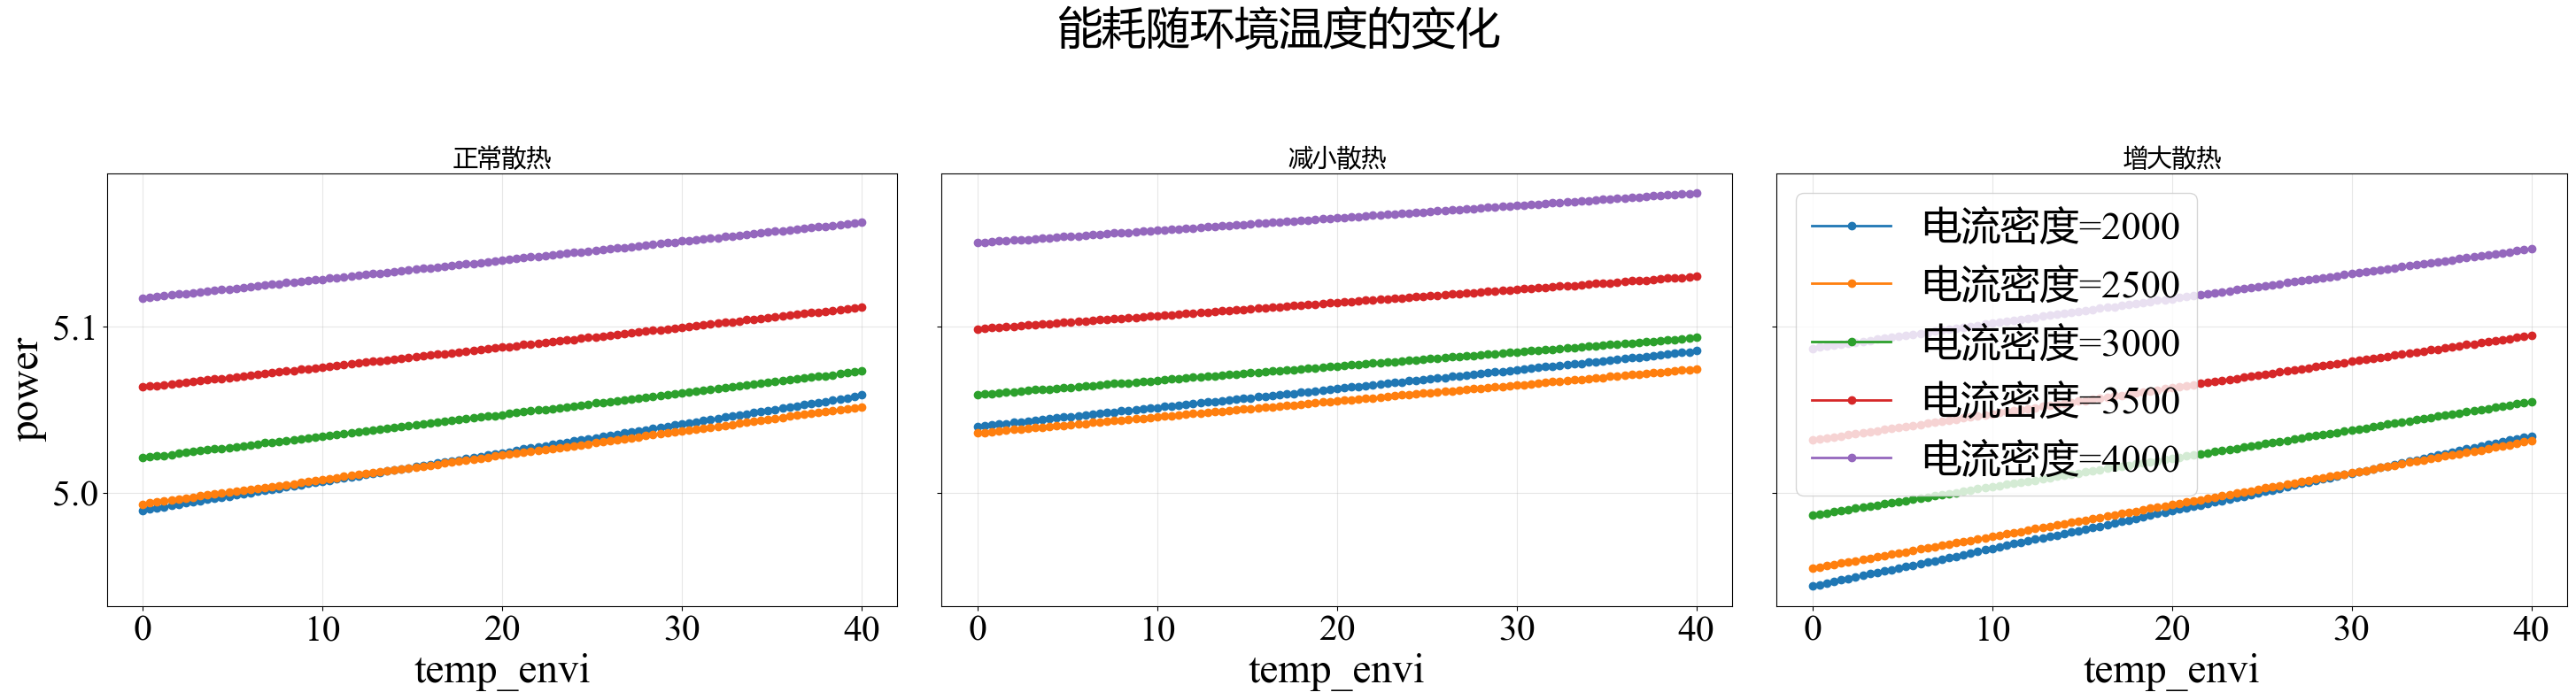

In [49]:
cases = [
    ("正常散热", df_all_01),
    ("减小散热", df_all_02),
    ("增大散热", df_all_03),
]

fig, axes = plt.subplots(1, 3, figsize=(30, 8), sharex=True, sharey=True)

for ax, (case_name, df_case) in zip(axes, cases):
    for current_density in current_density_array:
        df_sel = df_case[
            np.isclose(df_case["lye_flow"], 0.5) &
            (df_case["current_density"] == current_density)
        ].sort_values("temp_envi")

        ax.plot(
            df_sel["temp_envi"],
            df_sel["power"],
            marker="o",
            linewidth=2,
            label=f"电流密度={int(current_density)}"
        )

    ax.set_title(case_name)
    ax.set_xlabel("temp_envi")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("power")
axes[-1].legend(loc="best")  # 只在最后一张放图例，避免遮挡
fig.suptitle("能耗随环境温度的变化", y=1.02)
plt.tight_layout()
plt.show()

## 不同电密下，环境温度变化时最优工况对应的碱液流量和碱液温度

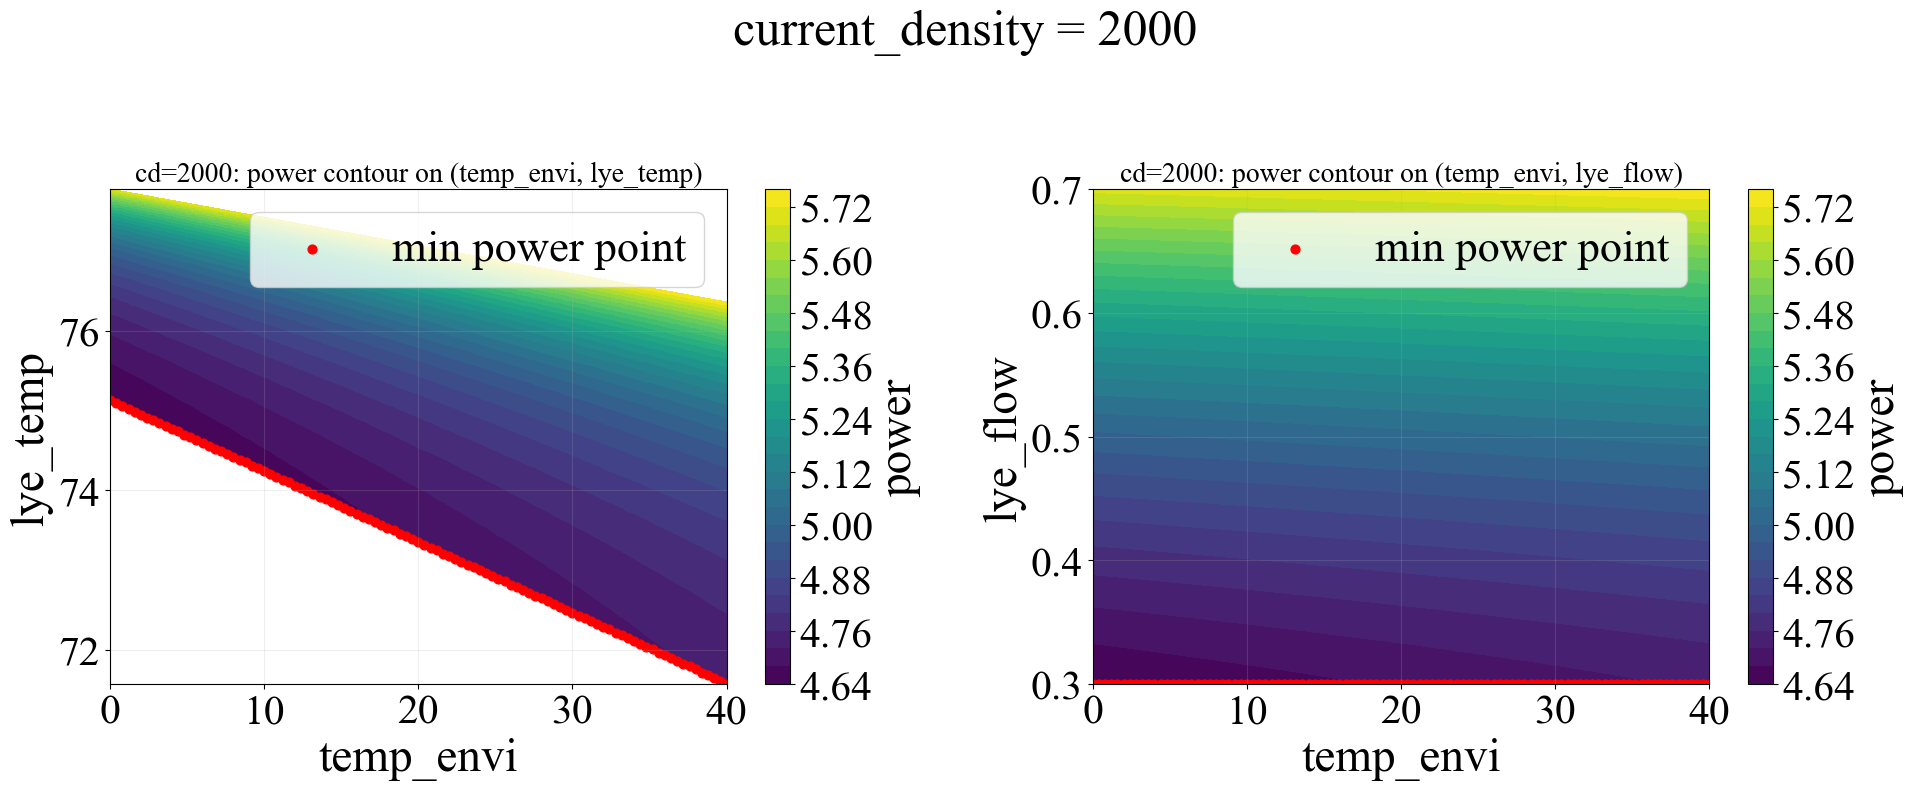

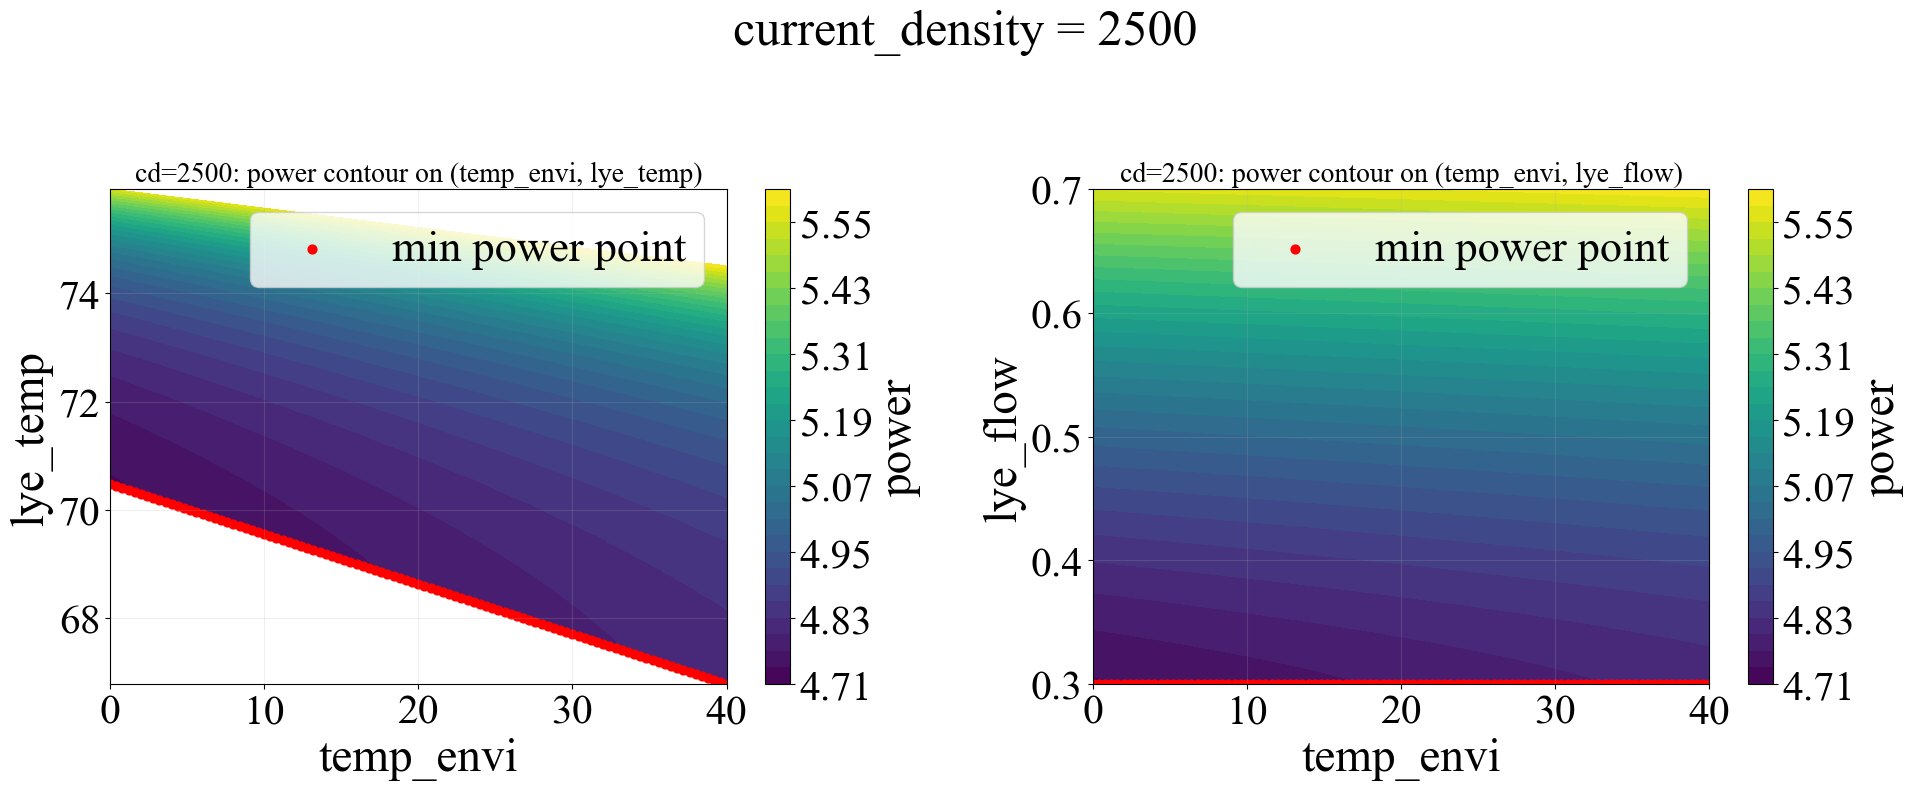

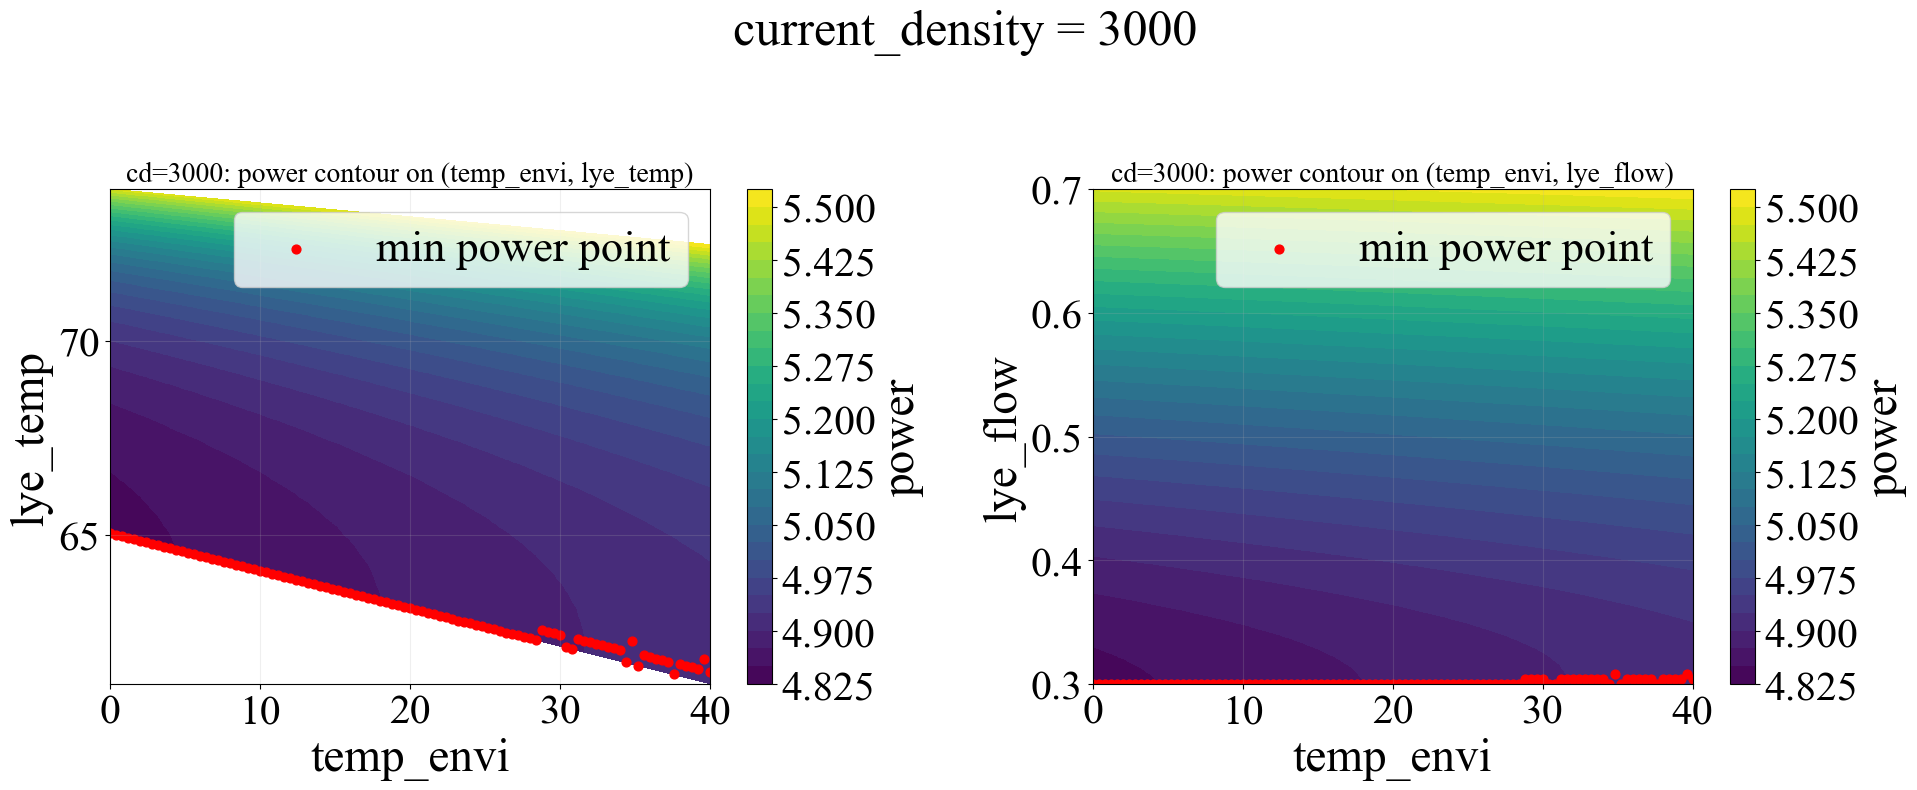

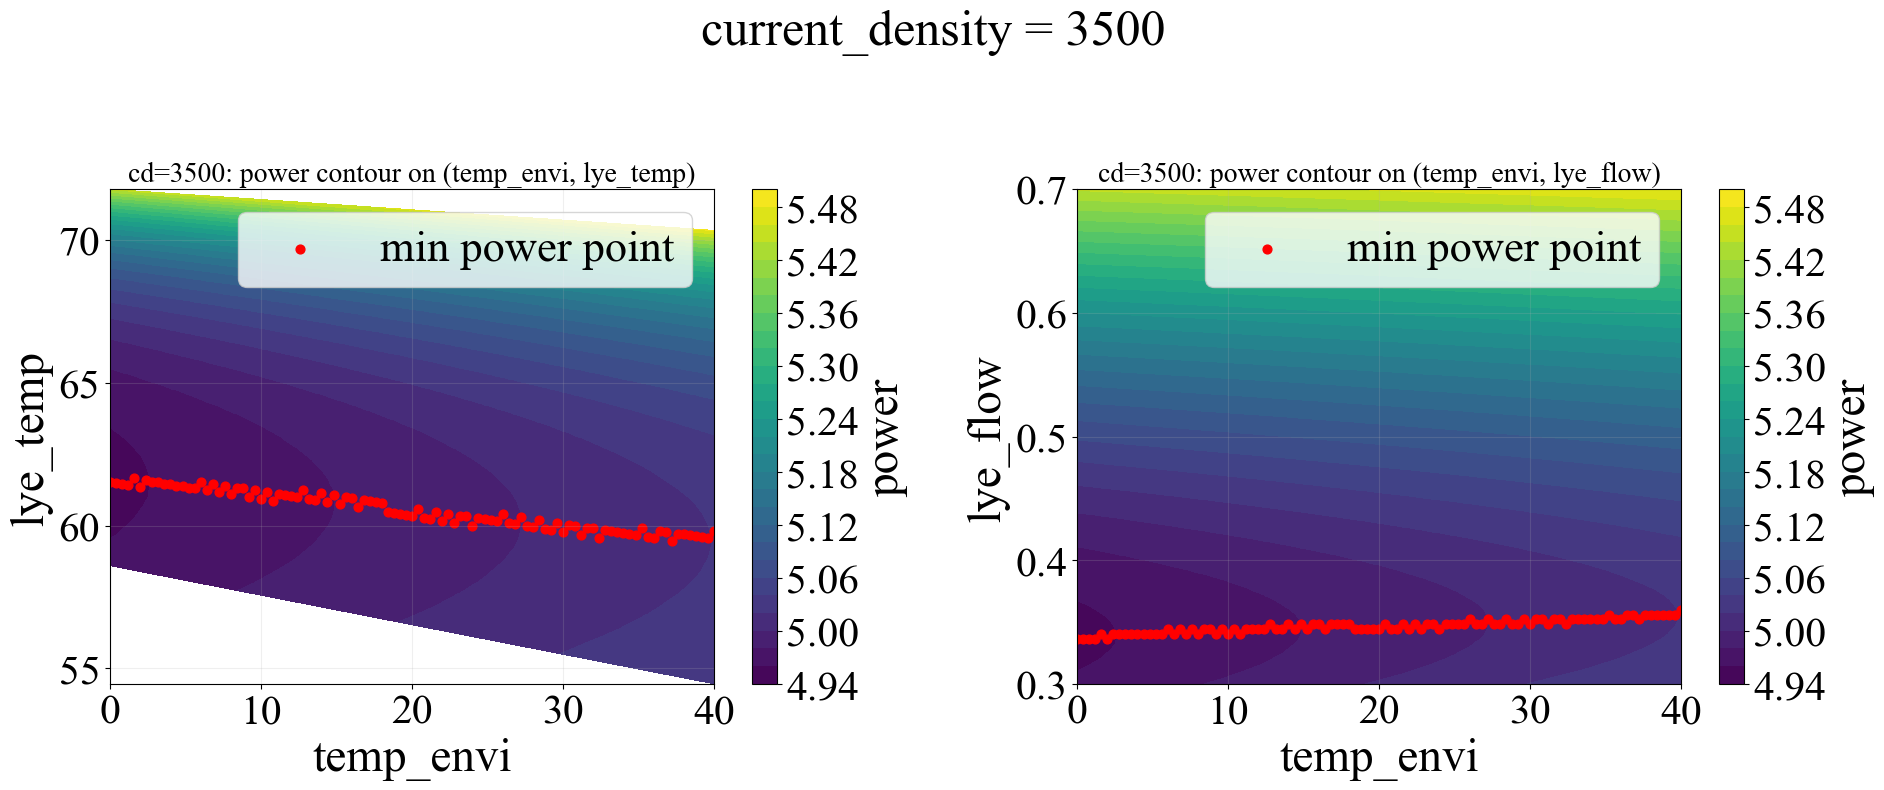

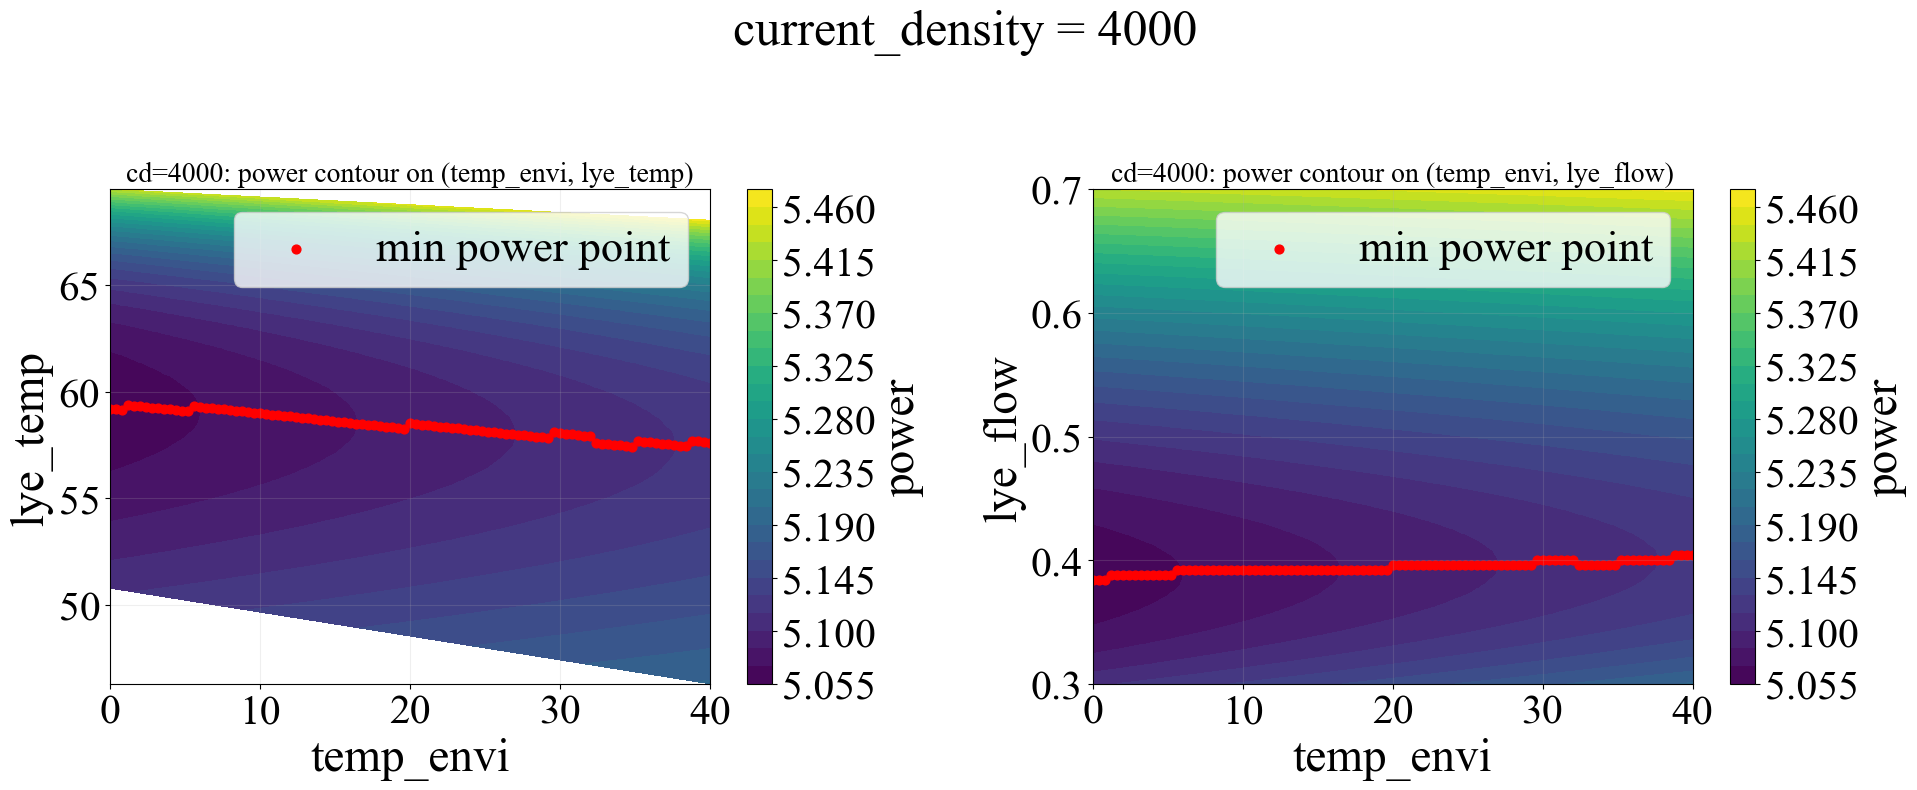

In [ ]:
# 可选：让等高线更细腻
levels = 30

for current_density in current_density_array:
    df_cd = df_all_01[df_all_01["current_density"] == current_density].copy()

    # 每个 temp_envi 下 power 最小的那一行（对应最优点）
    idx_best = df_cd.groupby("temp_envi")["power"].idxmin()
    df_best = df_cd.loc[idx_best].sort_values("temp_envi")

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # ---------- 左图：temp_envi - lye_temp - power ----------
    cs1 = axes[0].tricontourf(
        df_cd["temp_envi"].to_numpy(),
        df_cd["lye_temp"].to_numpy(),
        df_cd["power"].to_numpy(),
        levels=levels,
        cmap="viridis"
    )
    axes[0].scatter(
        df_best["temp_envi"],
        df_best["lye_temp"],
        c="red",
        s=40,
        label="min power point"
    )
    axes[0].set_xlabel("temp_envi")
    axes[0].set_ylabel("lye_temp")
    axes[0].set_title(f"cd={int(current_density)}: power contour on (temp_envi, lye_temp)")
    axes[0].grid(True, alpha=0.2)
    axes[0].legend(loc="best")
    cbar1 = fig.colorbar(cs1, ax=axes[0])
    cbar1.set_label("power")

    # ---------- 右图：temp_envi - lye_flow - power ----------
    cs2 = axes[1].tricontourf(
        df_cd["temp_envi"].to_numpy(),
        df_cd["lye_flow"].to_numpy(),
        df_cd["power"].to_numpy(),
        levels=levels,
        cmap="viridis"
    )
    axes[1].scatter(
        df_best["temp_envi"],
        df_best["lye_flow"],
        c="red",
        s=40,
        label="min power point"
    )
    axes[1].set_xlabel("temp_envi")
    axes[1].set_ylabel("lye_flow")
    axes[1].set_title(f"cd={int(current_density)}: power contour on (temp_envi, lye_flow)")
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(loc="best")
    cbar2 = fig.colorbar(cs2, ax=axes[1])
    cbar2.set_label("power")

    fig.suptitle(f"current_density = {int(current_density)}", y=1.02)
    plt.tight_layout()
    plt.show()

## 减小电解槽散热能力，开展计算

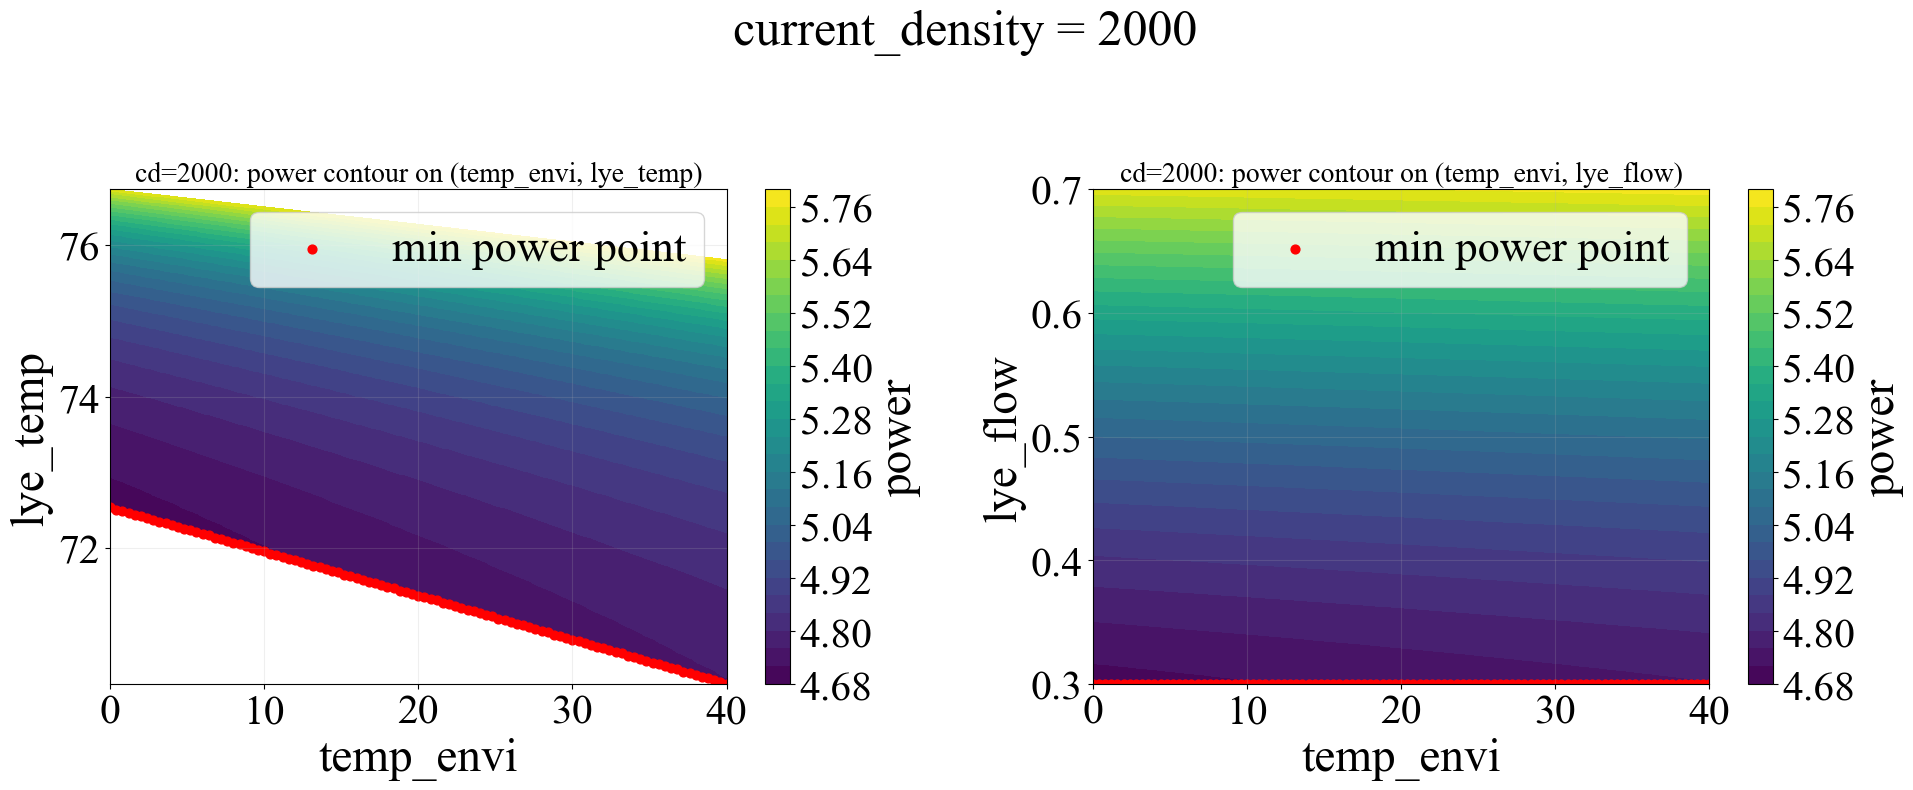

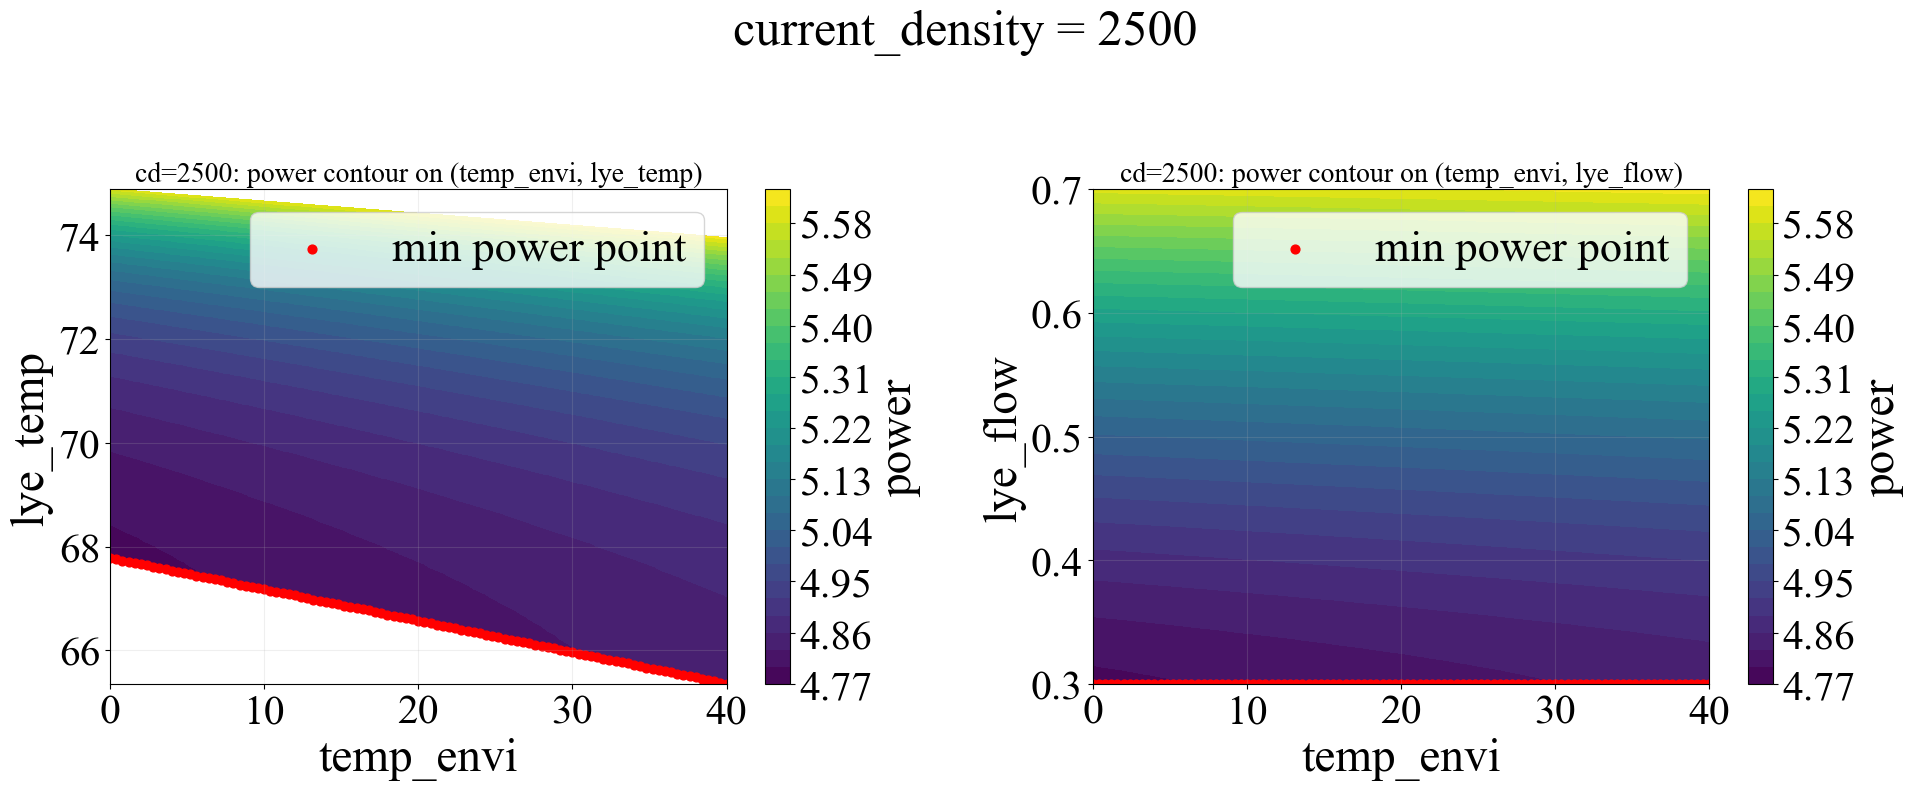

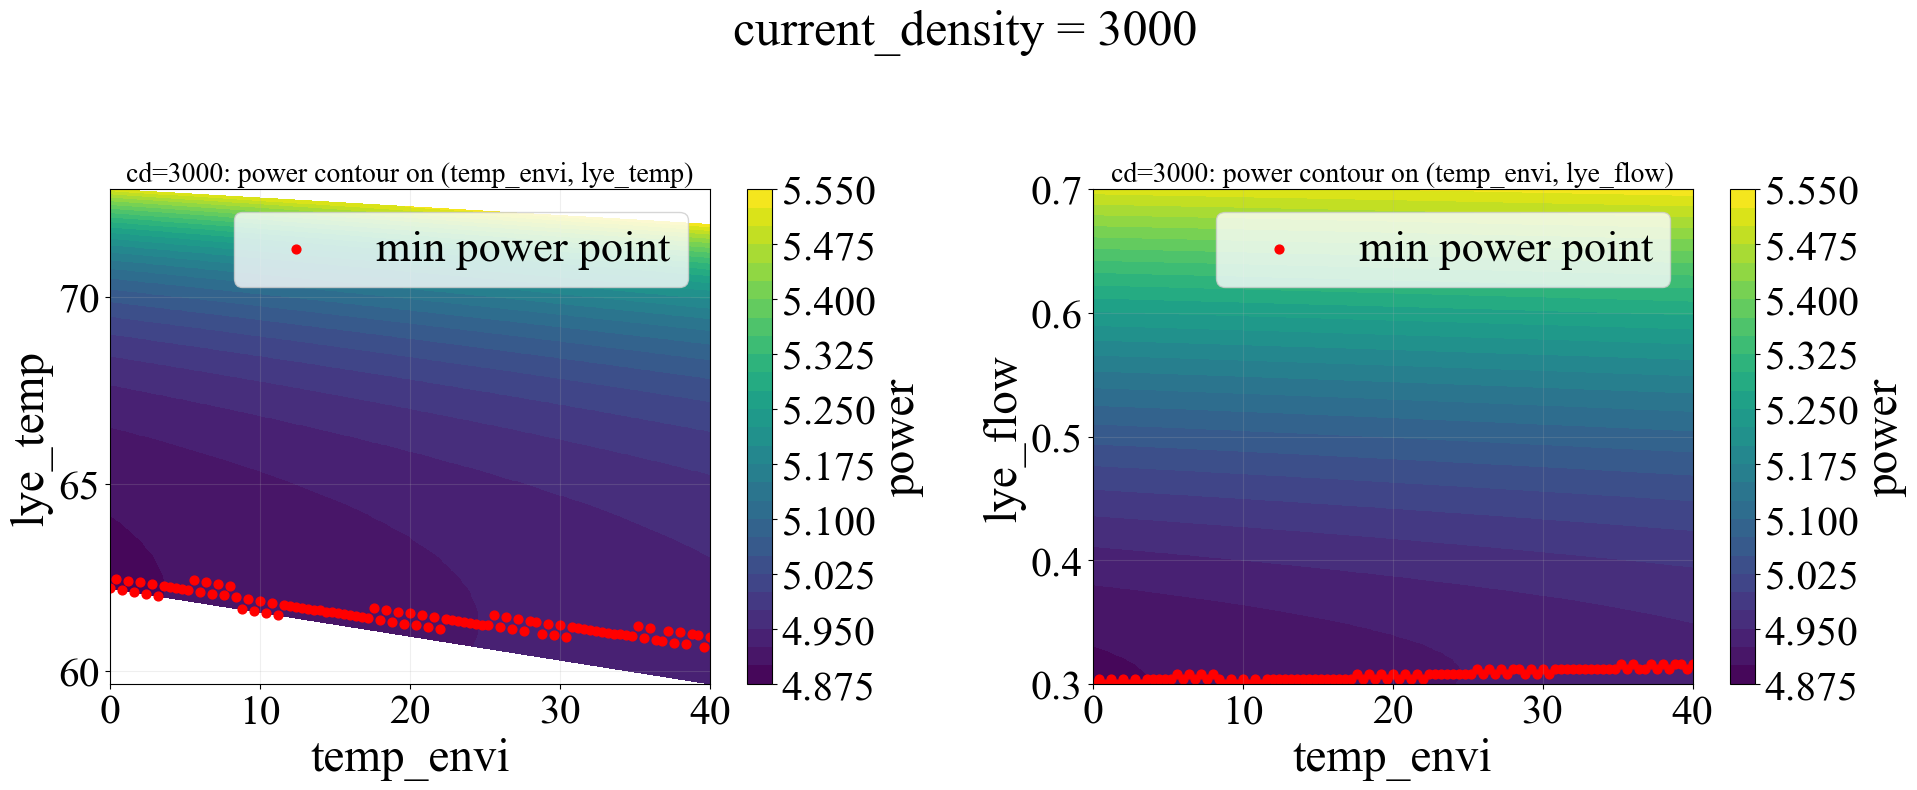

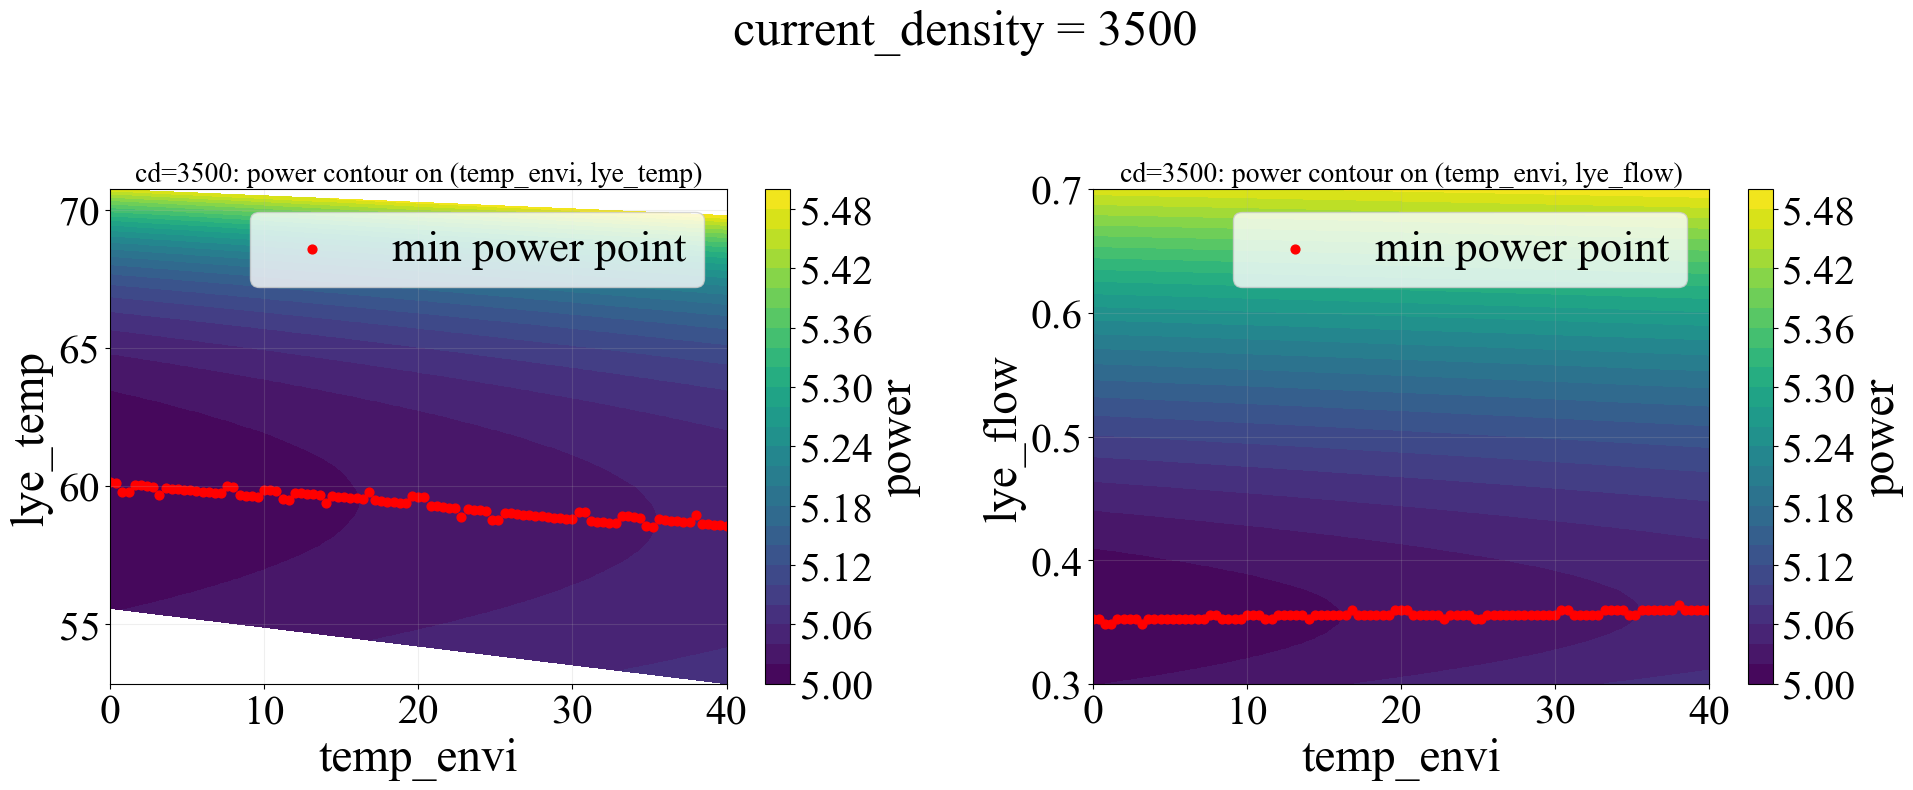

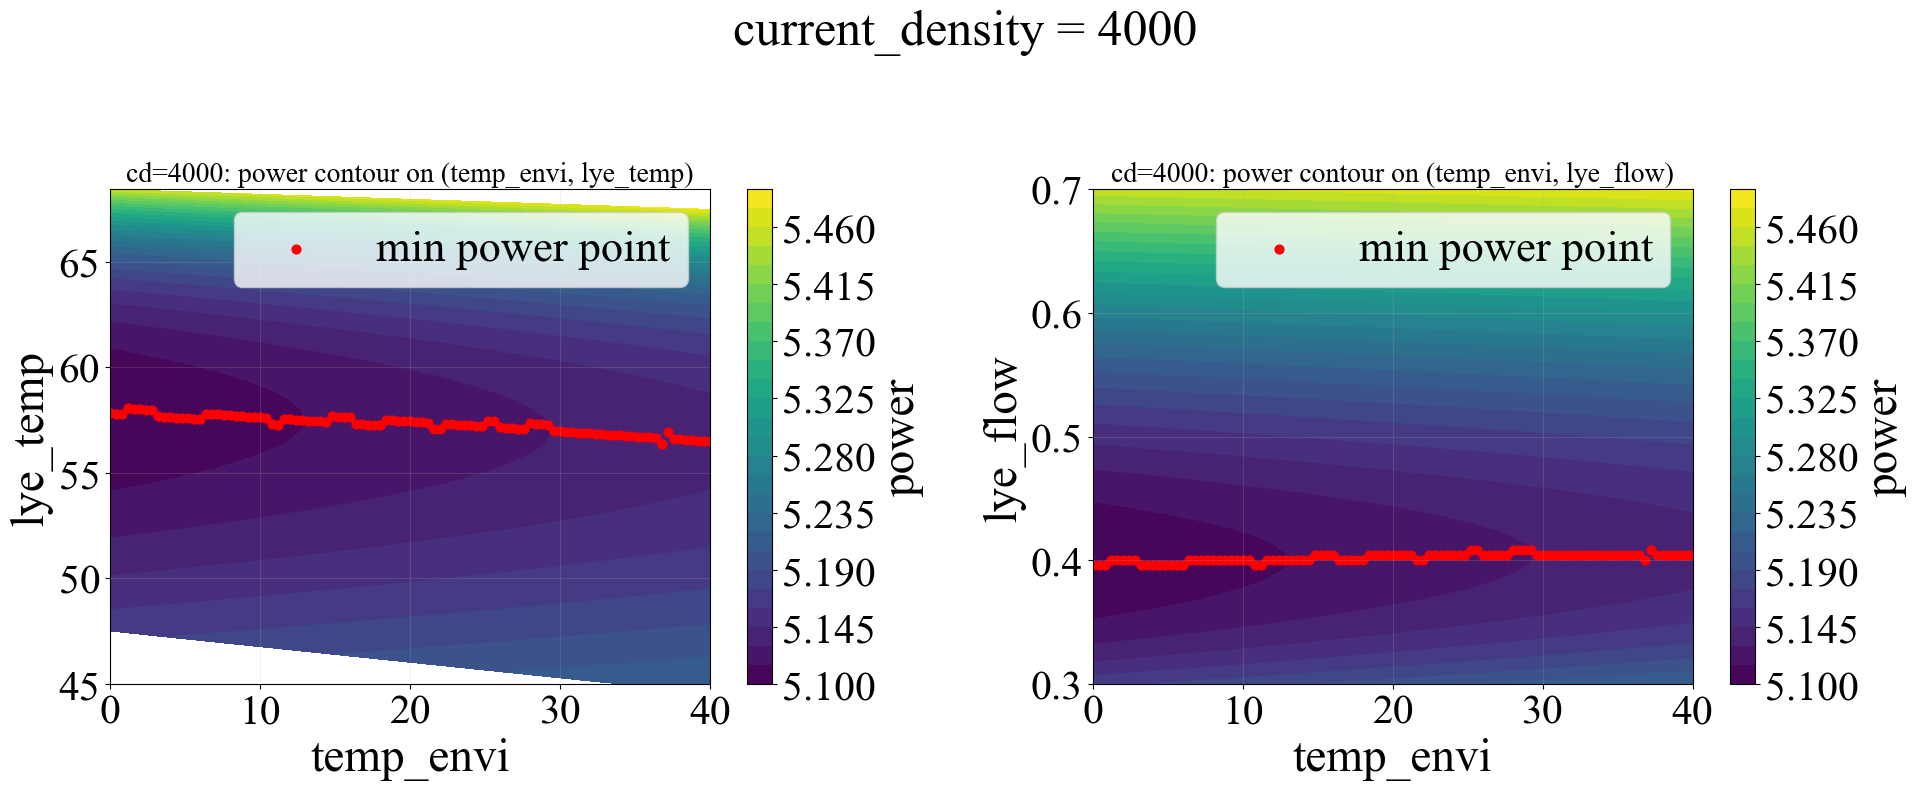

In [5]:
levels = 30

for current_density in current_density_array:
    df_cd = df_all_02[df_all_02["current_density"] == current_density].copy()

    # 每个 temp_envi 下 power 最小的那一行（对应最优点）
    idx_best = df_cd.groupby("temp_envi")["power"].idxmin()
    df_best = df_cd.loc[idx_best].sort_values("temp_envi")

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # ---------- 左图：temp_envi - lye_temp - power ----------
    cs1 = axes[0].tricontourf(
        df_cd["temp_envi"].to_numpy(),
        df_cd["lye_temp"].to_numpy(),
        df_cd["power"].to_numpy(),
        levels=levels,
        cmap="viridis"
    )
    axes[0].scatter(
        df_best["temp_envi"],
        df_best["lye_temp"],
        c="red",
        s=40,
        label="min power point"
    )
    axes[0].set_xlabel("temp_envi")
    axes[0].set_ylabel("lye_temp")
    axes[0].set_title(f"cd={int(current_density)}: power contour on (temp_envi, lye_temp)")
    axes[0].grid(True, alpha=0.2)
    axes[0].legend(loc="best")
    cbar1 = fig.colorbar(cs1, ax=axes[0])
    cbar1.set_label("power")

    # ---------- 右图：temp_envi - lye_flow - power ----------
    cs2 = axes[1].tricontourf(
        df_cd["temp_envi"].to_numpy(),
        df_cd["lye_flow"].to_numpy(),
        df_cd["power"].to_numpy(),
        levels=levels,
        cmap="viridis"
    )
    axes[1].scatter(
        df_best["temp_envi"],
        df_best["lye_flow"],
        c="red",
        s=40,
        label="min power point"
    )
    axes[1].set_xlabel("temp_envi")
    axes[1].set_ylabel("lye_flow")
    axes[1].set_title(f"cd={int(current_density)}: power contour on (temp_envi, lye_flow)")
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(loc="best")
    cbar2 = fig.colorbar(cs2, ax=axes[1])
    cbar2.set_label("power")

    fig.suptitle(f"current_density = {int(current_density)}", y=1.02)
    plt.tight_layout()
    plt.show()

## 增大电解槽散热能力，开展计算

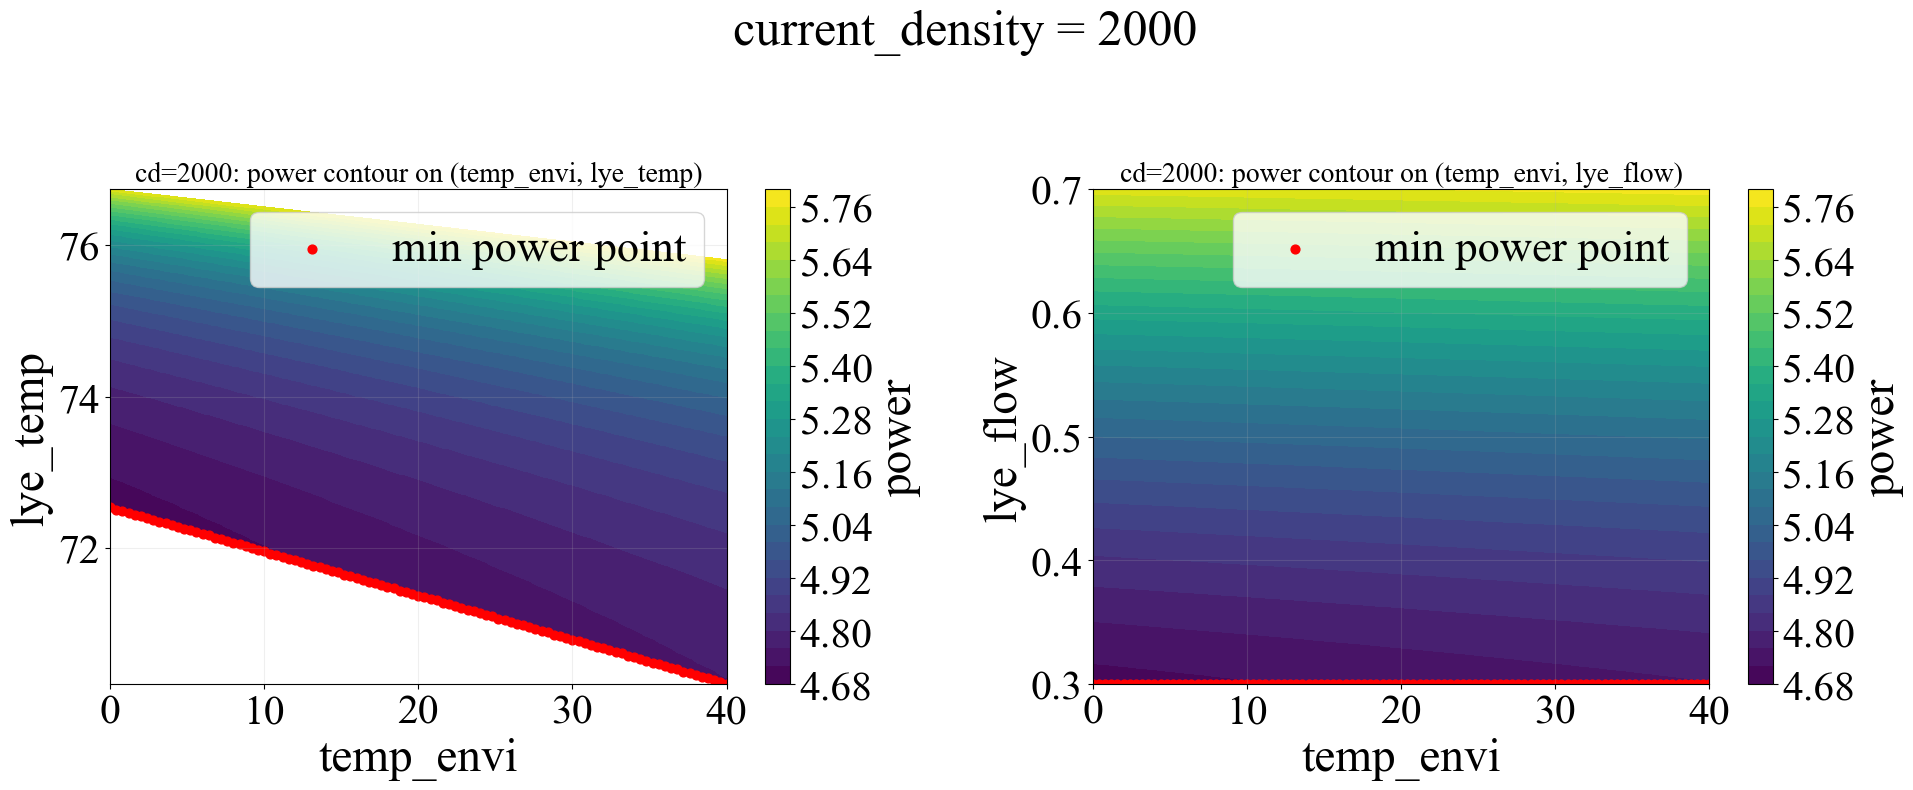

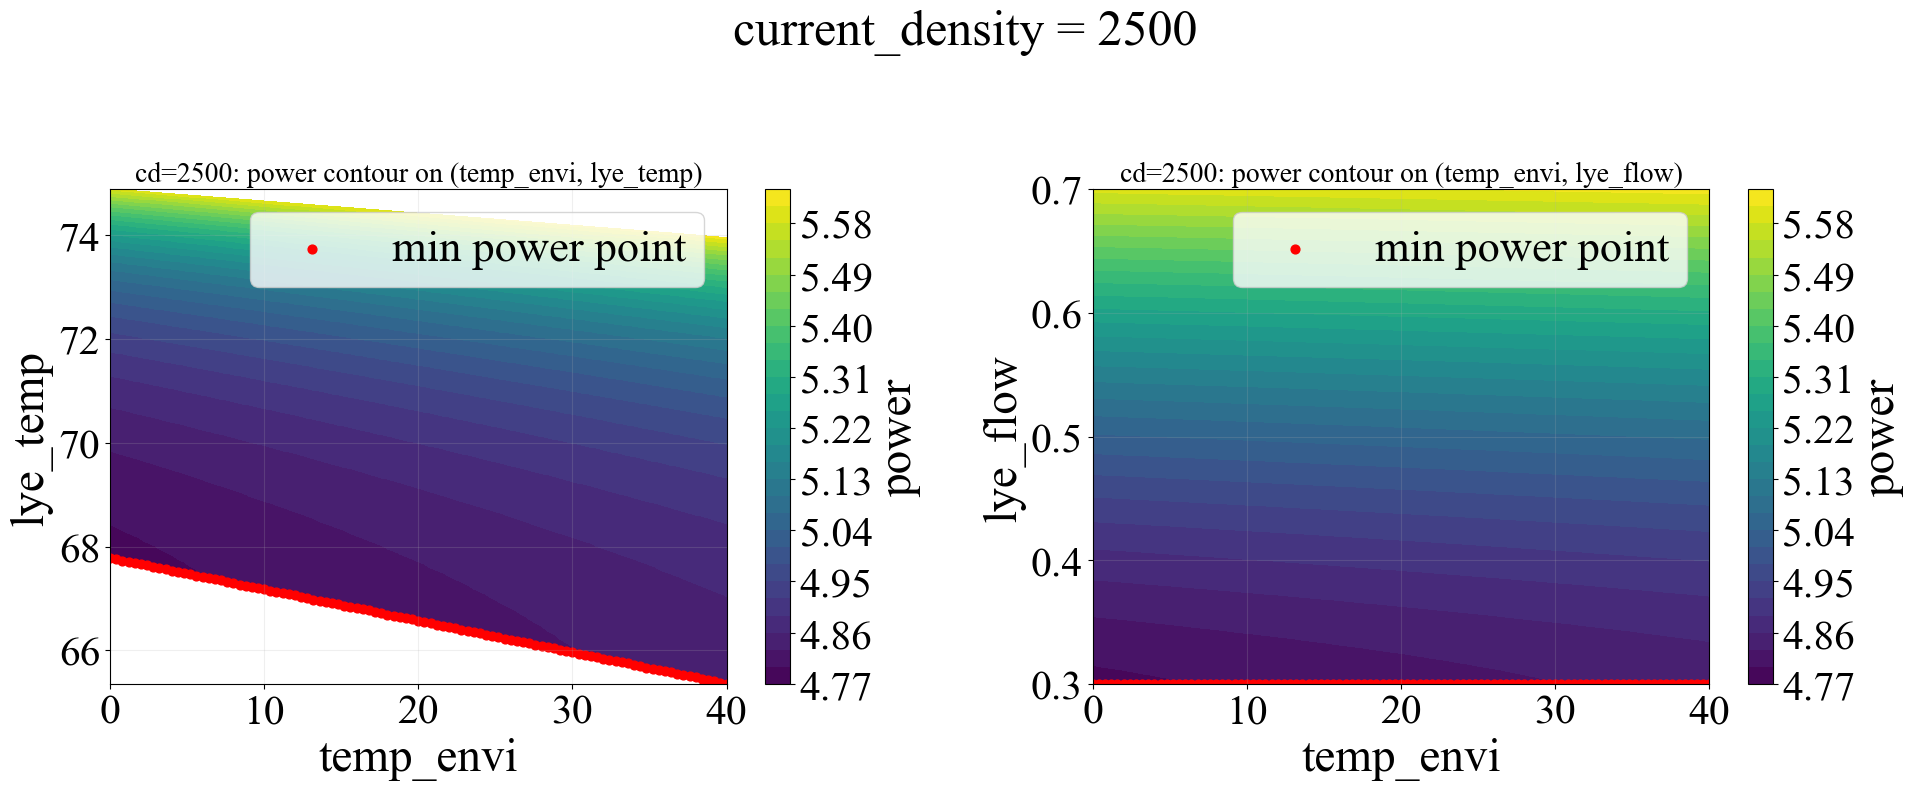

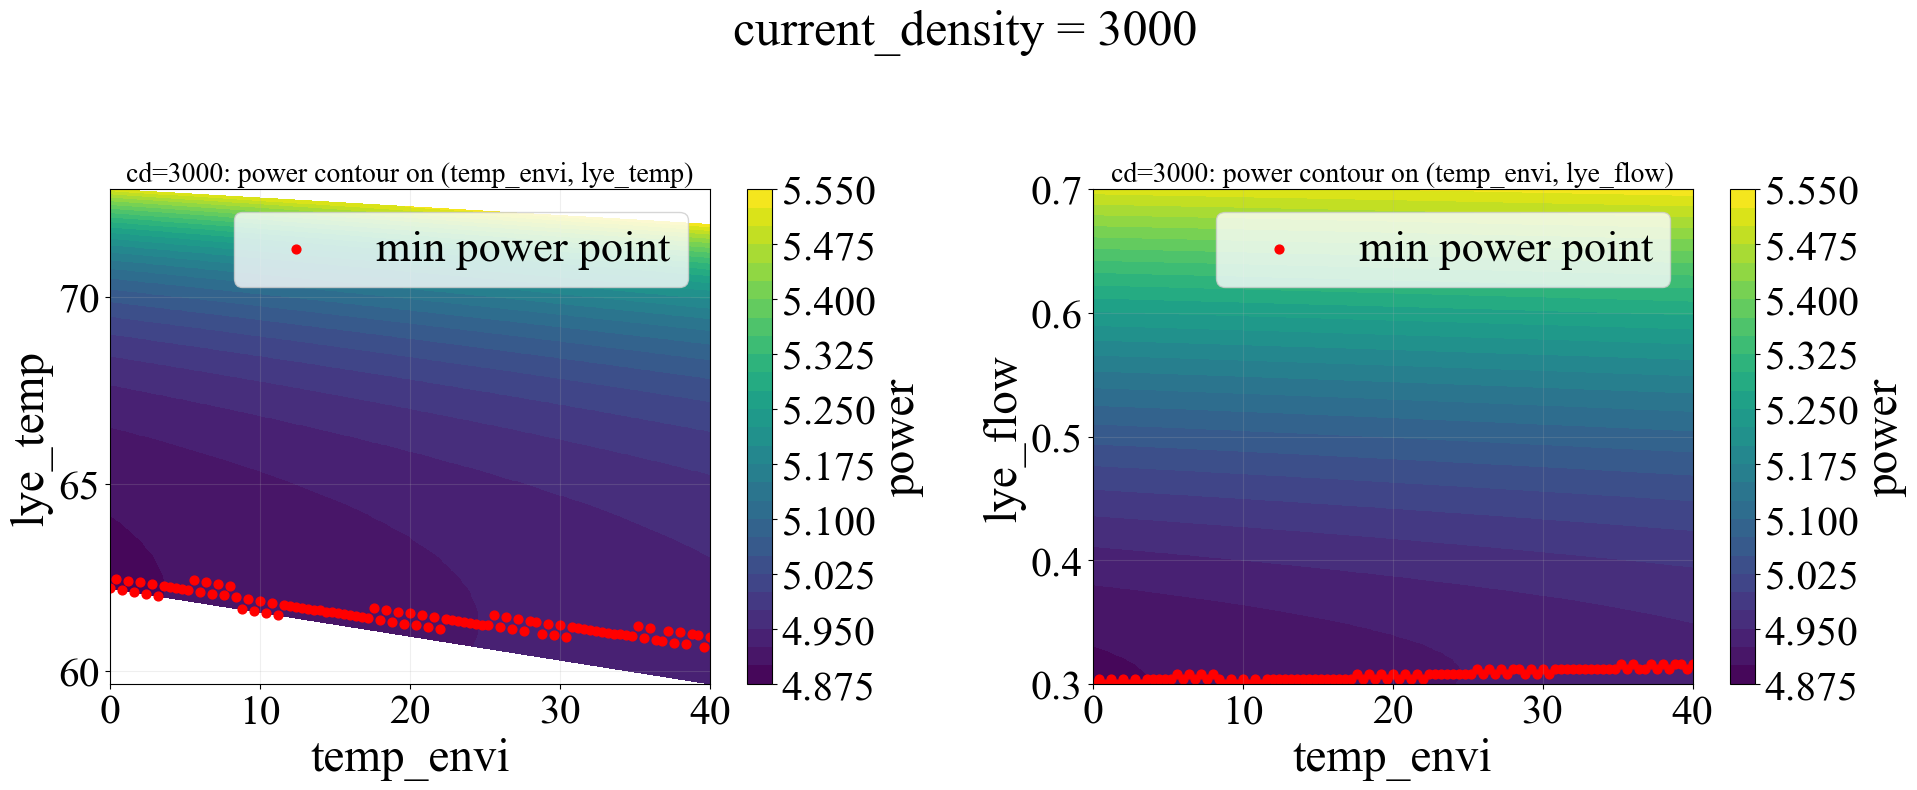

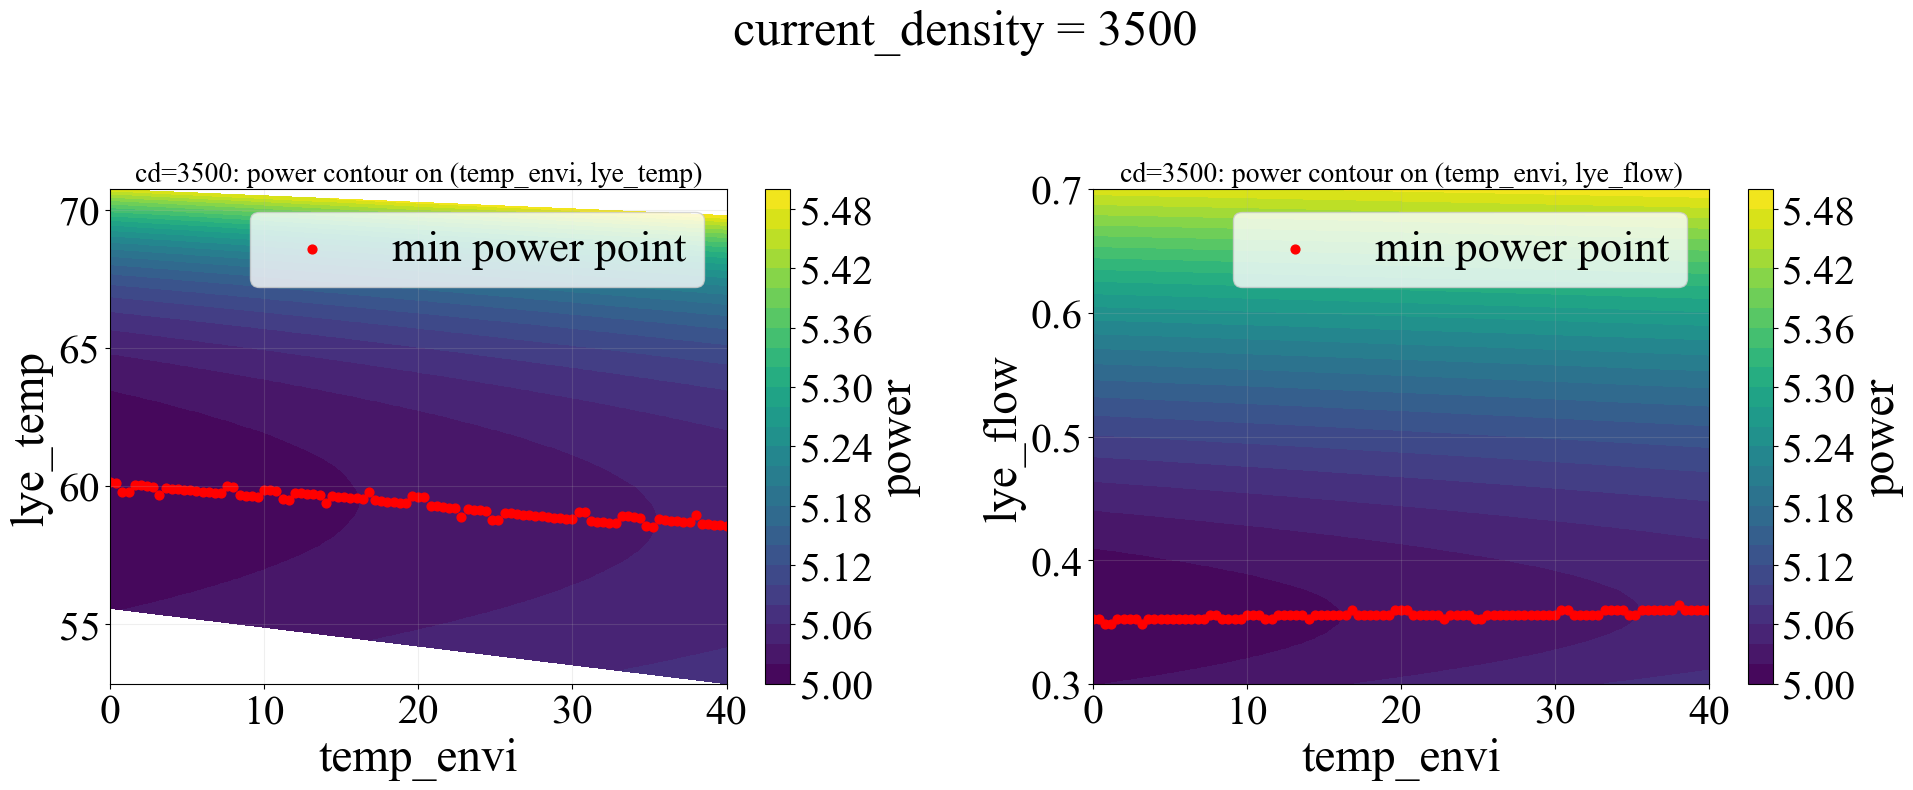

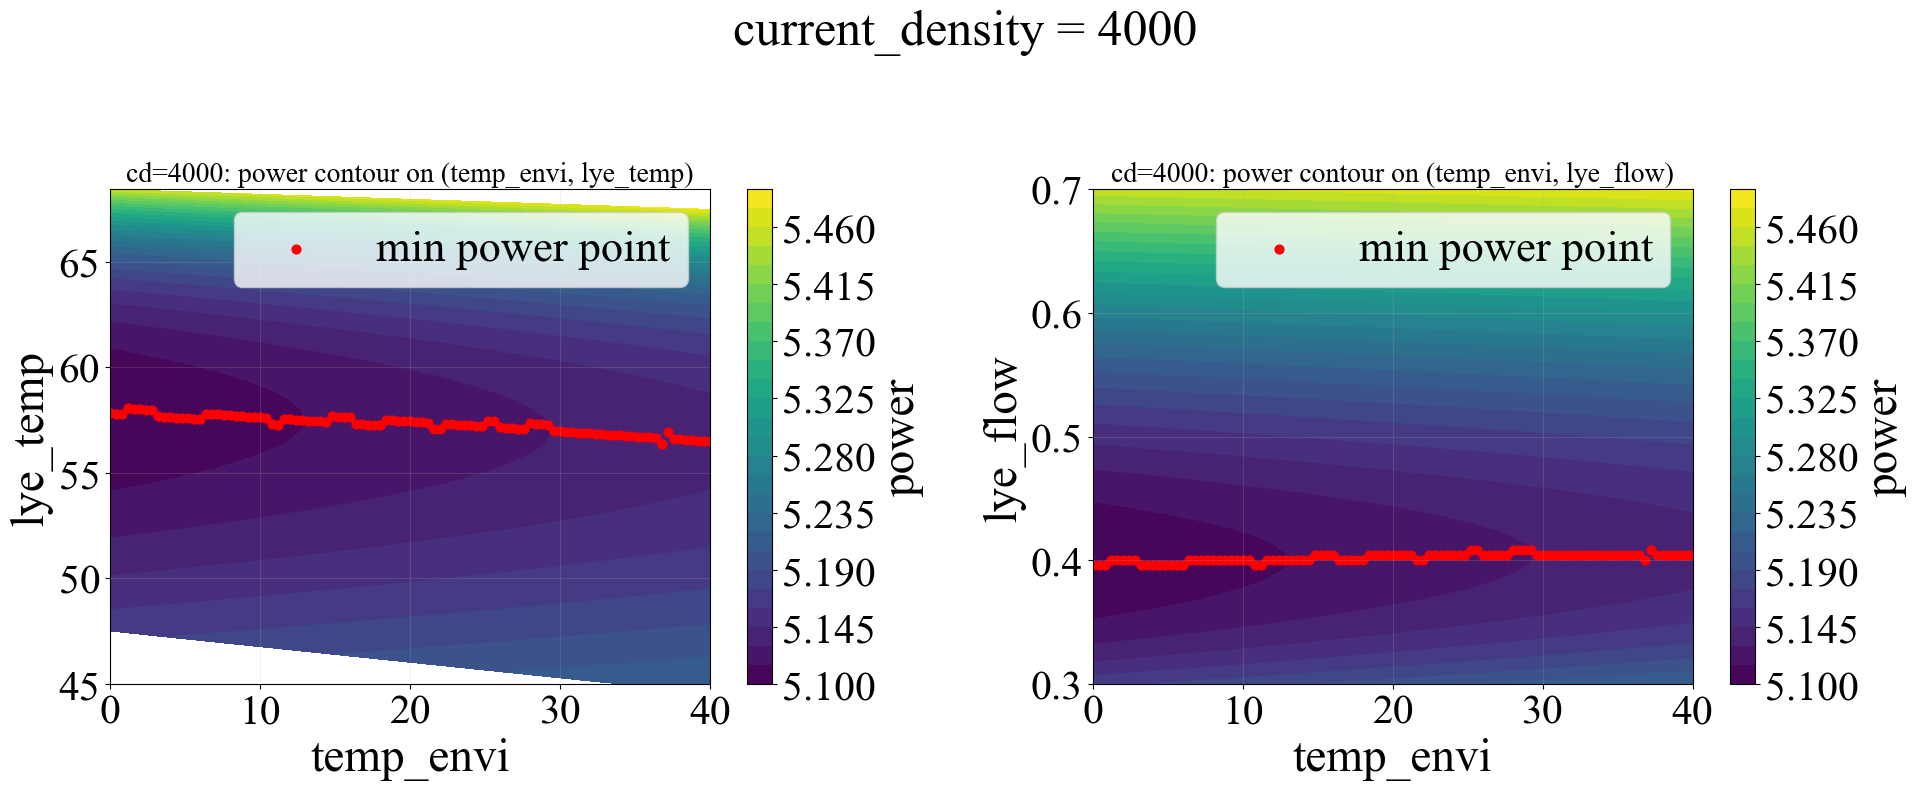

In [6]:
levels = 30

for current_density in current_density_array:
    df_cd = df_all_02[df_all_02["current_density"] == current_density].copy()

    # 每个 temp_envi 下 power 最小的那一行（对应最优点）
    idx_best = df_cd.groupby("temp_envi")["power"].idxmin()
    df_best = df_cd.loc[idx_best].sort_values("temp_envi")

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # ---------- 左图：temp_envi - lye_temp - power ----------
    cs1 = axes[0].tricontourf(
        df_cd["temp_envi"].to_numpy(),
        df_cd["lye_temp"].to_numpy(),
        df_cd["power"].to_numpy(),
        levels=levels,
        cmap="viridis"
    )
    axes[0].scatter(
        df_best["temp_envi"],
        df_best["lye_temp"],
        c="red",
        s=40,
        label="min power point"
    )
    axes[0].set_xlabel("temp_envi")
    axes[0].set_ylabel("lye_temp")
    axes[0].set_title(f"cd={int(current_density)}: power contour on (temp_envi, lye_temp)")
    axes[0].grid(True, alpha=0.2)
    axes[0].legend(loc="best")
    cbar1 = fig.colorbar(cs1, ax=axes[0])
    cbar1.set_label("power")

    # ---------- 右图：temp_envi - lye_flow - power ----------
    cs2 = axes[1].tricontourf(
        df_cd["temp_envi"].to_numpy(),
        df_cd["lye_flow"].to_numpy(),
        df_cd["power"].to_numpy(),
        levels=levels,
        cmap="viridis"
    )
    axes[1].scatter(
        df_best["temp_envi"],
        df_best["lye_flow"],
        c="red",
        s=40,
        label="min power point"
    )
    axes[1].set_xlabel("temp_envi")
    axes[1].set_ylabel("lye_flow")
    axes[1].set_title(f"cd={int(current_density)}: power contour on (temp_envi, lye_flow)")
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(loc="best")
    cbar2 = fig.colorbar(cs2, ax=axes[1])
    cbar2.set_label("power")

    fig.suptitle(f"current_density = {int(current_density)}", y=1.02)
    plt.tight_layout()
    plt.show()

## 不同散热能力下，最优工况对应碱液温度和碱液流量的变化

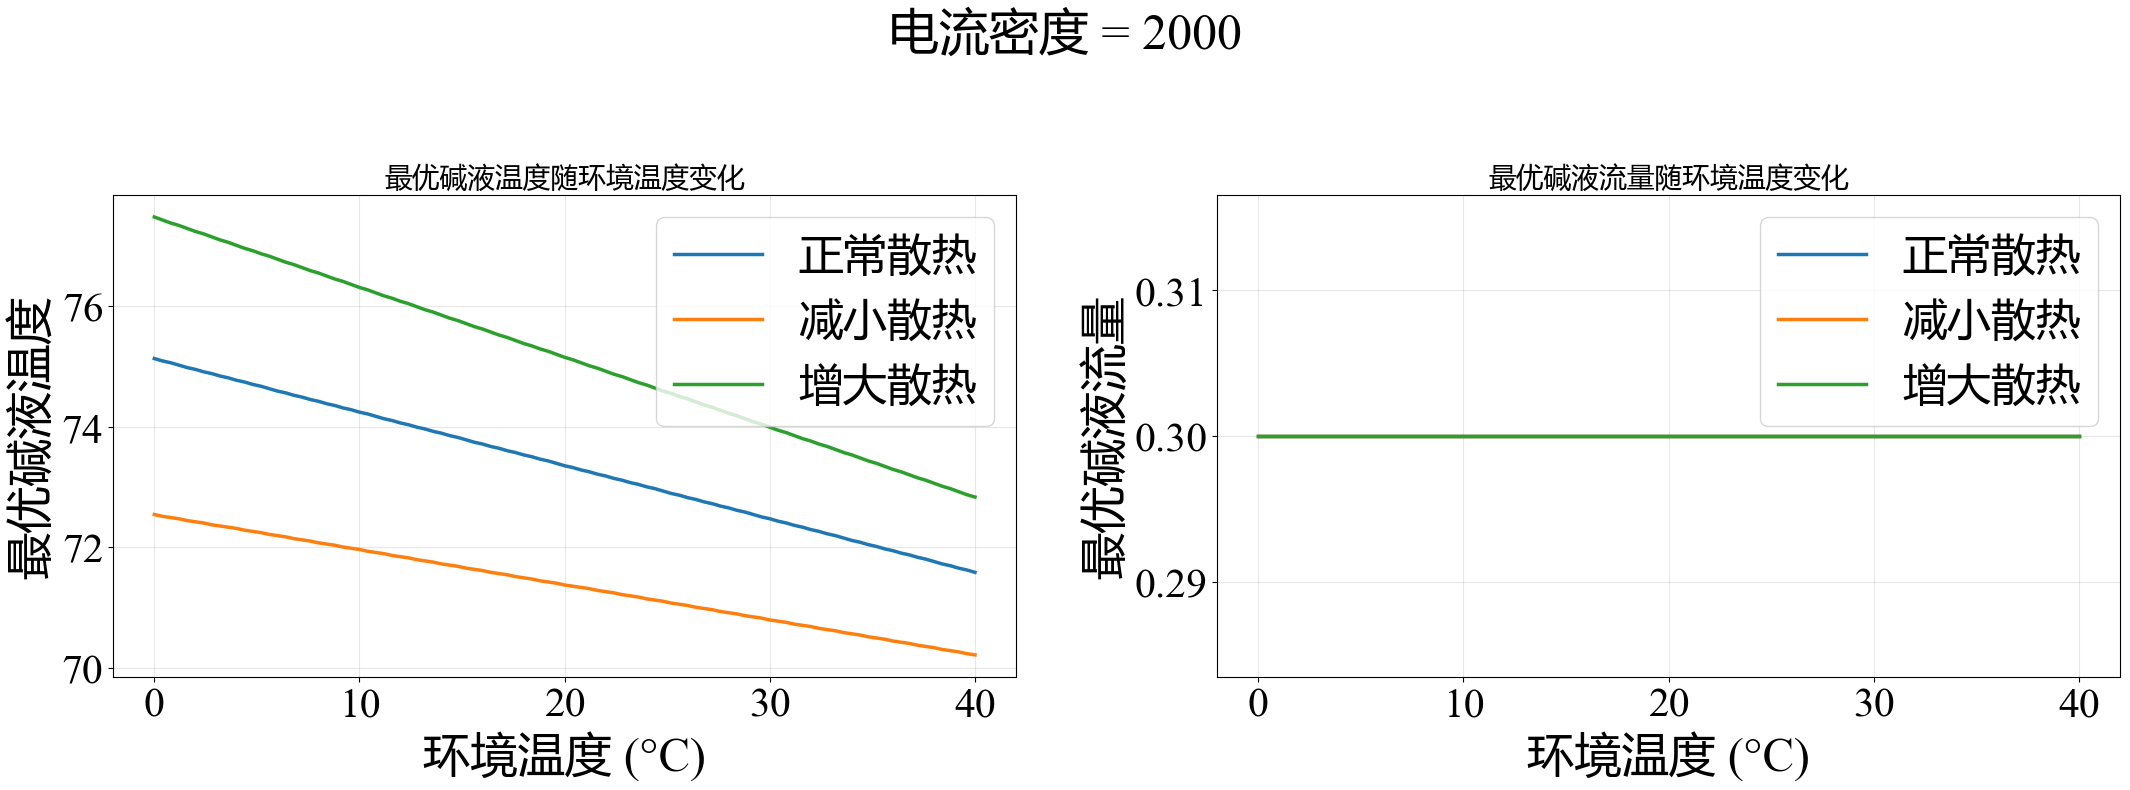

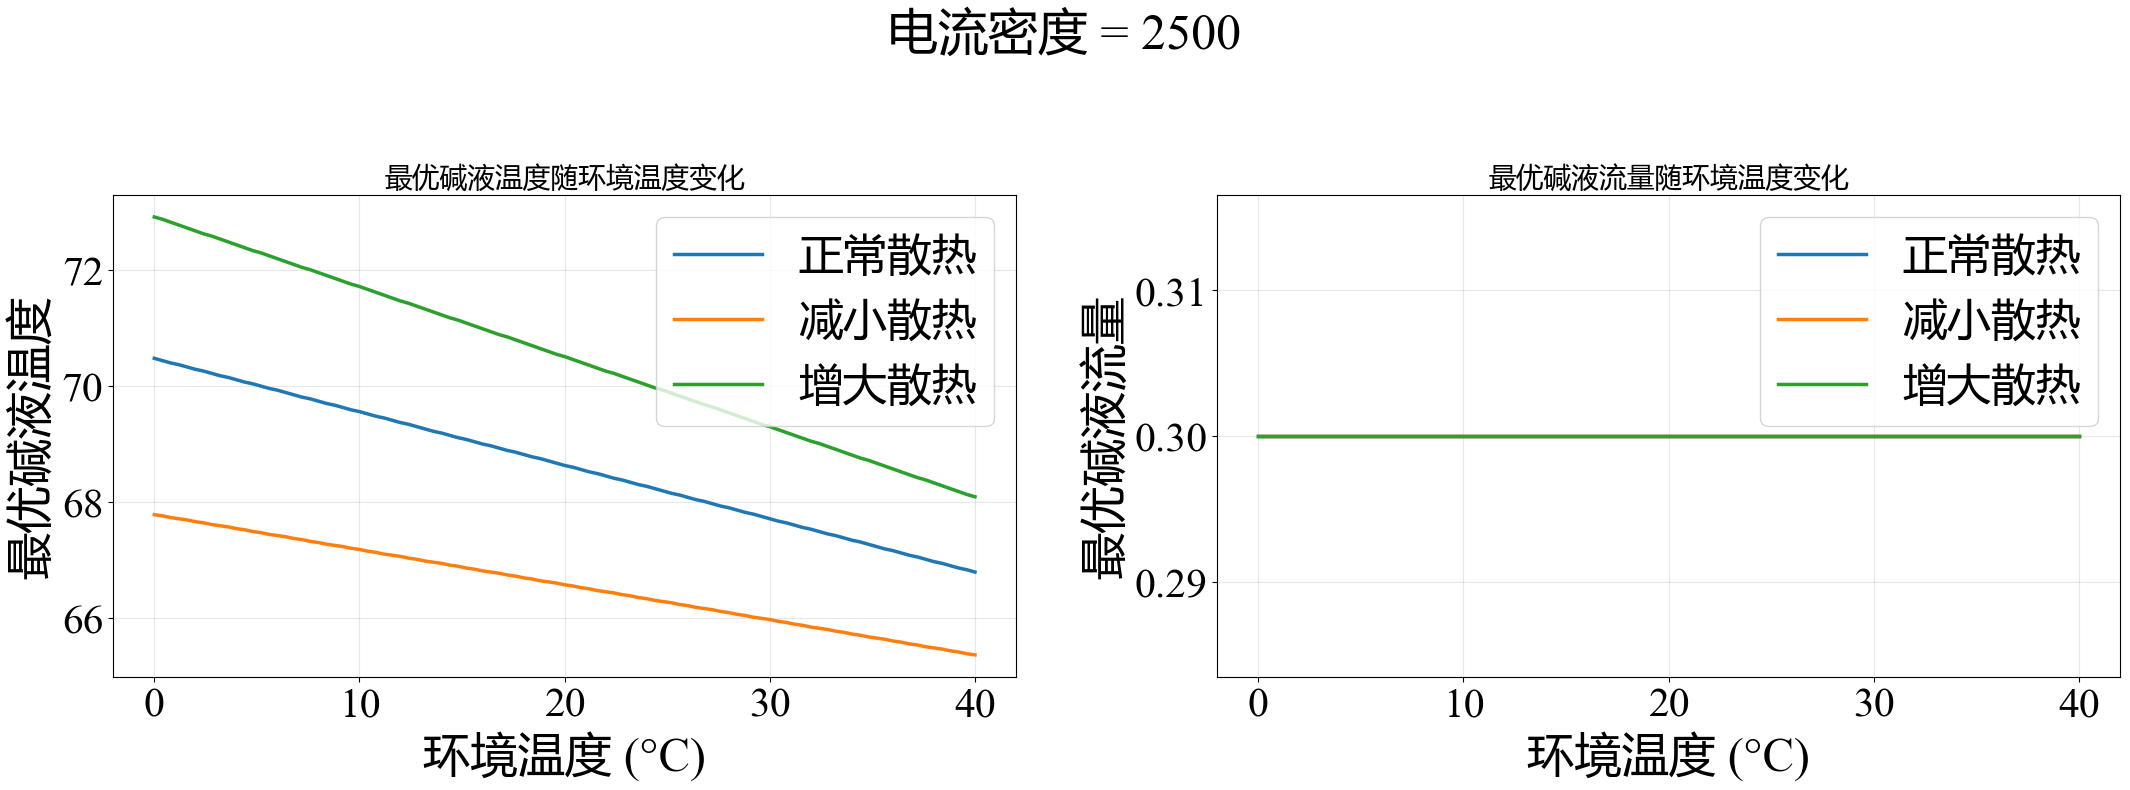

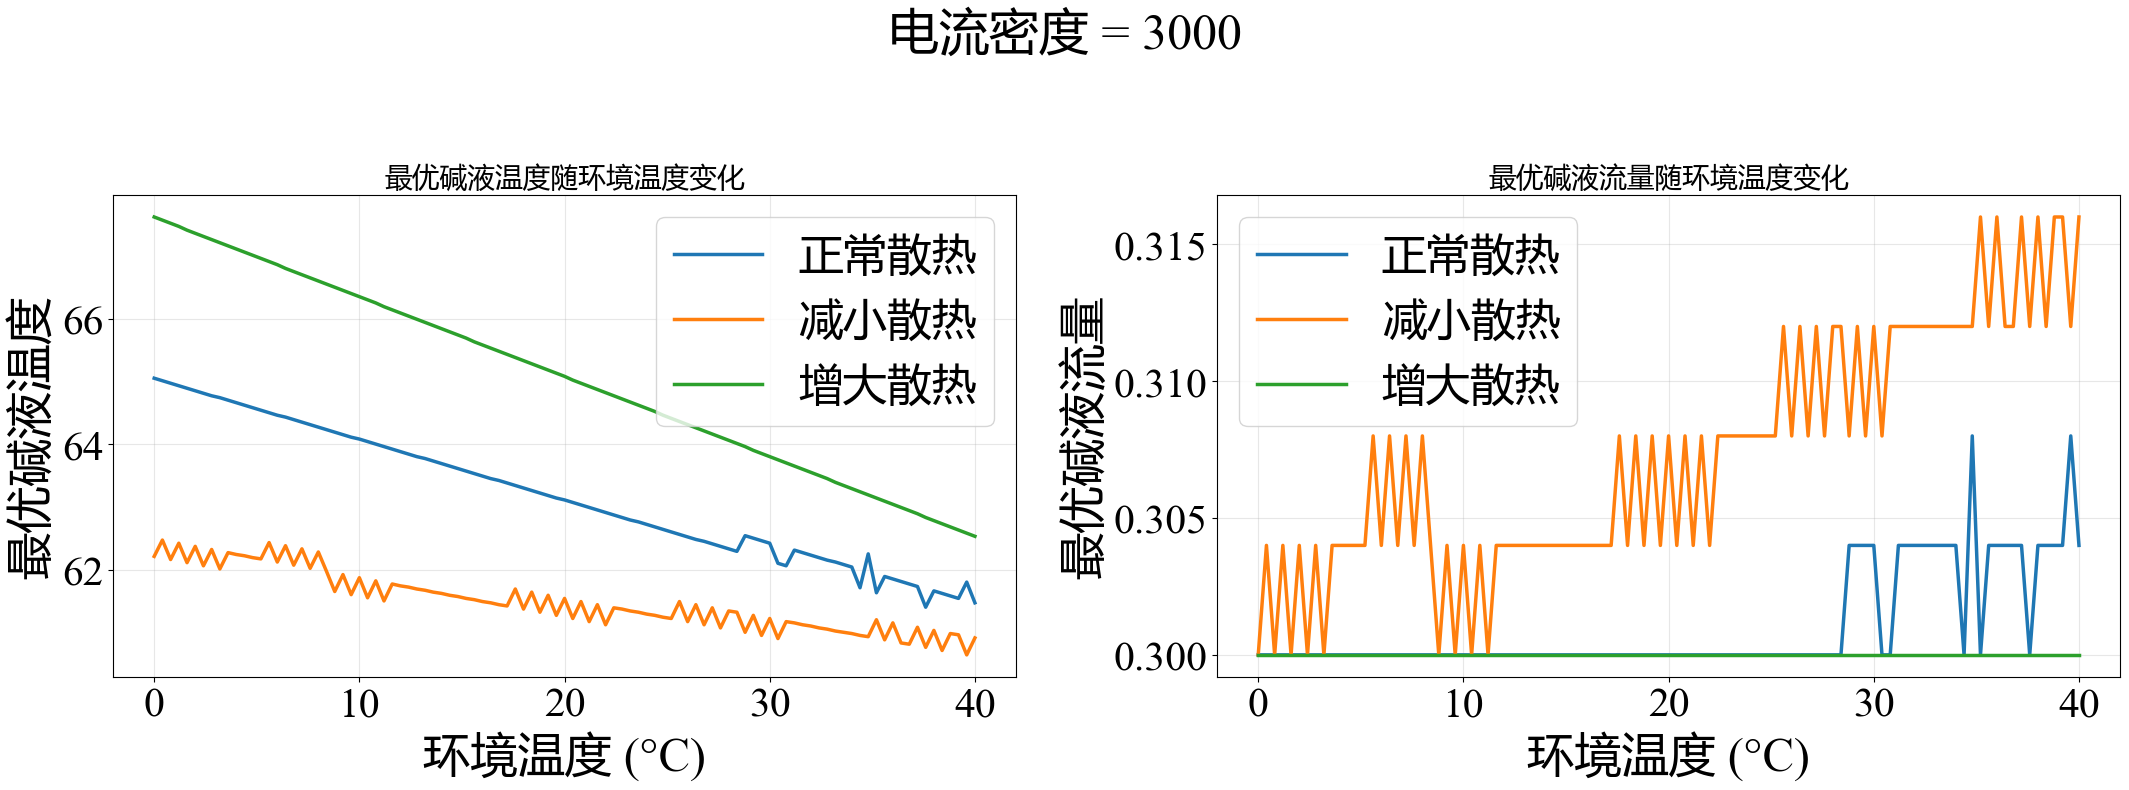

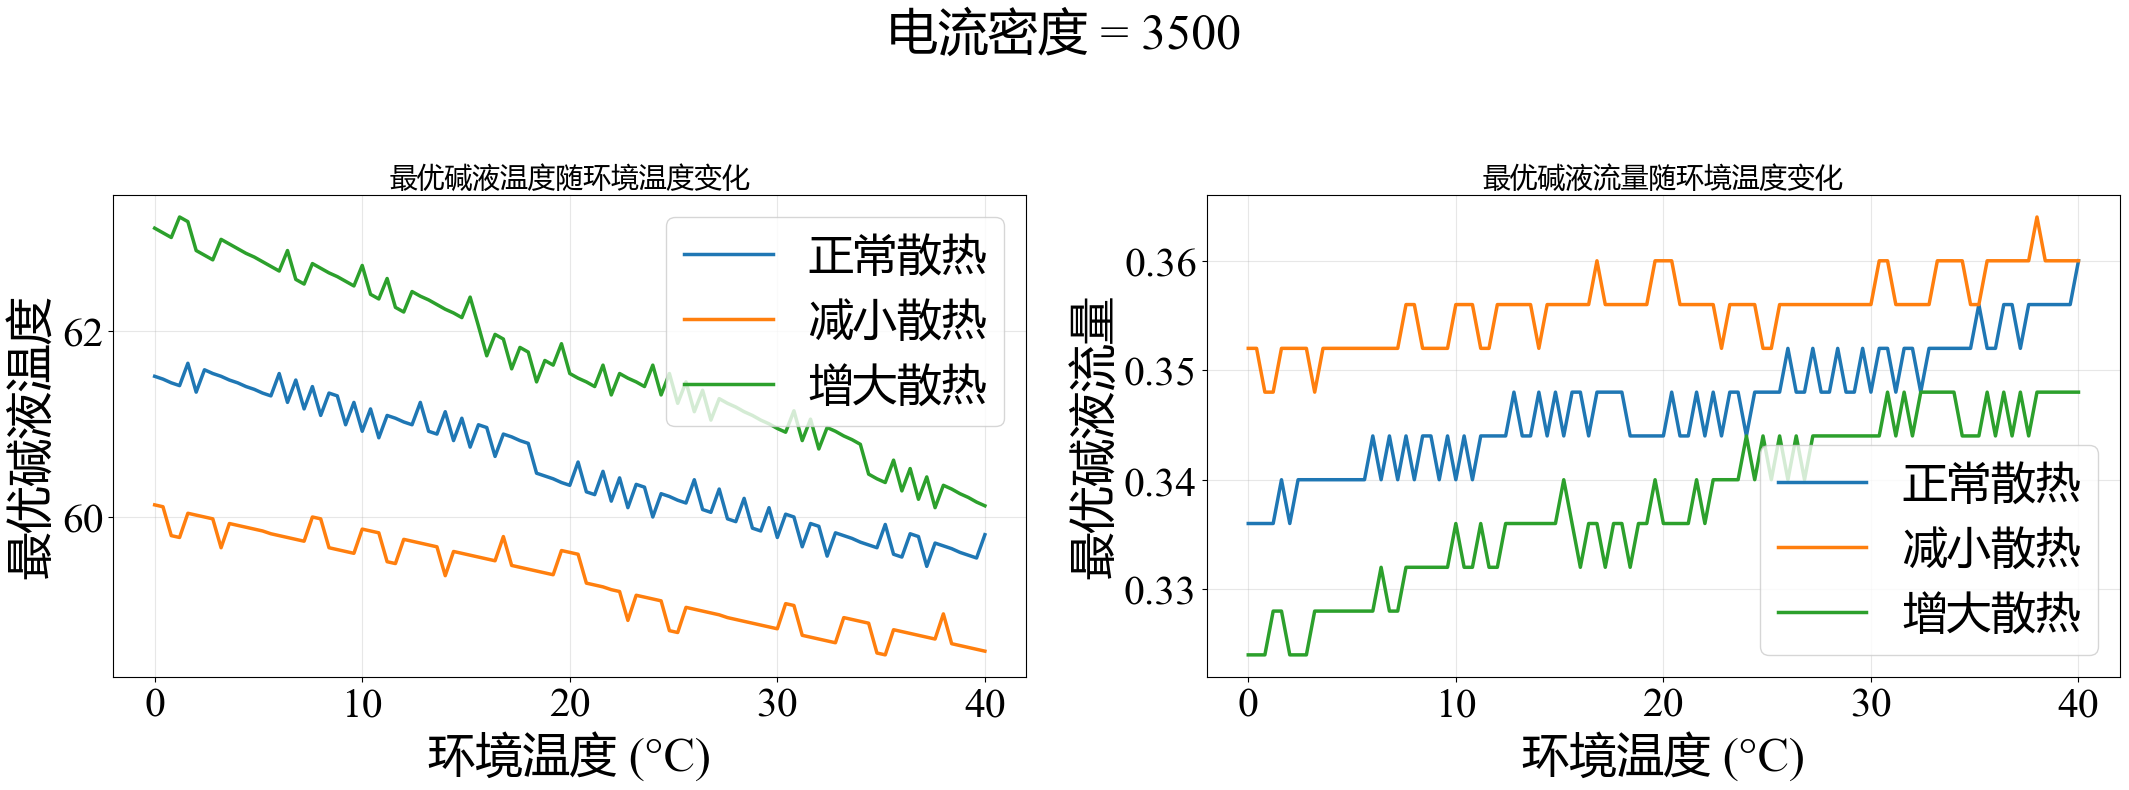

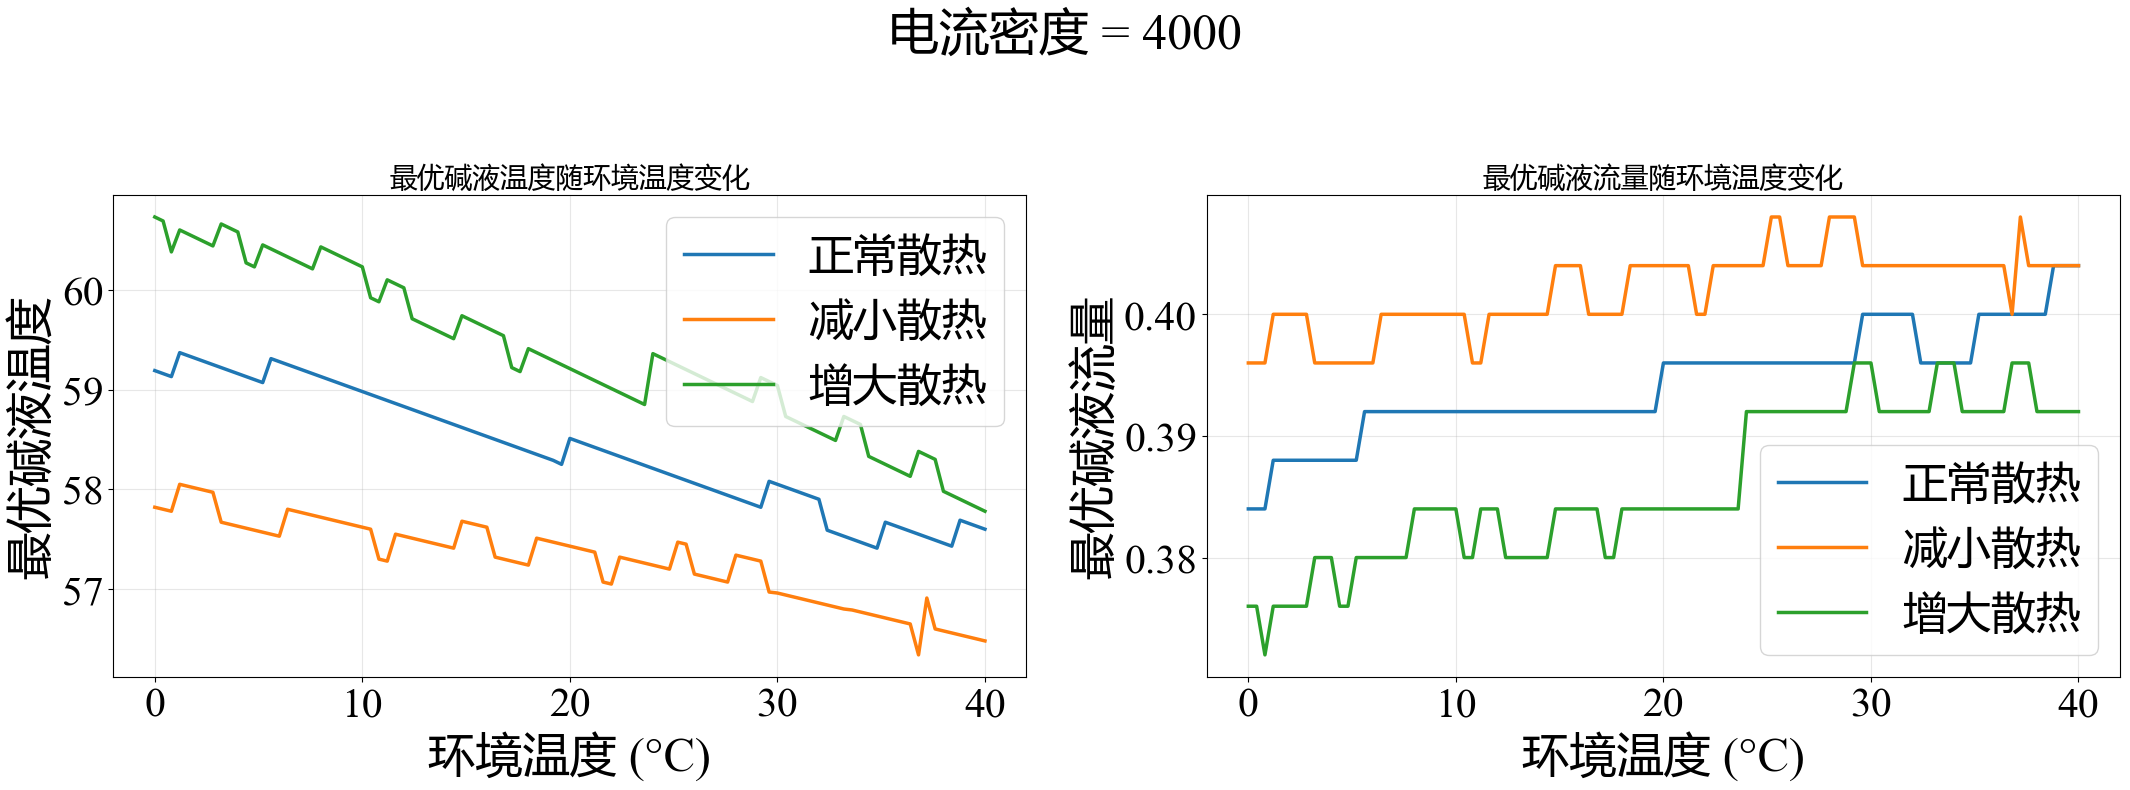

In [7]:
cases = [
    ("正常散热", df_all_01),
    ("减小散热", df_all_02),
    ("增大散热", df_all_03),
]

for current_density in current_density_array:
    fig, axes = plt.subplots(1, 2, figsize=(22, 8), sharex=True)

    for case_name, df_case in cases:
        df_cd = df_case[df_case["current_density"] == current_density].copy()

        # 每个环境温度下选择能耗最小的工况点
        idx_best = df_cd.groupby("temp_envi")["power"].idxmin()
        df_best = df_cd.loc[idx_best].sort_values("temp_envi")

        axes[0].plot(
            df_best["temp_envi"],
            df_best["lye_temp"],
            linewidth=2.5,
            label=case_name
        )
        axes[1].plot(
            df_best["temp_envi"],
            df_best["lye_flow"],
            linewidth=2.5,
            label=case_name
        )

    axes[0].set_xlabel("环境温度 (°C)")
    axes[0].set_ylabel("最优碱液温度")
    axes[0].set_title("最优碱液温度随环境温度变化")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel("环境温度 (°C)")
    axes[1].set_ylabel("最优碱液流量")
    axes[1].set_title("最优碱液流量随环境温度变化")
    axes[1].grid(True, alpha=0.3)

    axes[0].legend(loc="best")
    axes[1].legend(loc="best")

    fig.suptitle(f"电流密度 = {int(current_density)}", y=1.02)
    plt.tight_layout()
    plt.show()